In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

In [2]:
spark = SparkSession.builder \
    .appName("DataRisk") \
    .getOrCreate()

print(spark)

26/04/11 18:25:13 WARN Utils: Your hostname, gus-Latitude-3420 resolves to a loopback address: 127.0.1.1; using 192.168.0.97 instead (on interface wlp0s20f3)
26/04/11 18:25:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/11 18:25:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
base_cadastral = spark.read.parquet("../data/base_cadastral.parquet").toPandas()
base_submissao = spark.read.parquet("../data/base_submissao.parquet").toPandas()
historico_emprestimos = spark.read.parquet("../data/historico_emprestimos.parquet").toPandas()
historico_parcelas = spark.read.parquet("../data/historico_parcelas.parquet").toPandas()

26/04/11 18:25:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [ ]:
print(base_cadastral.shape)
print(base_submissao.shape)
print(historico_emprestimos.shape)
print(historico_parcelas.shape)

(40000, 16)
(40000, 8)
(186890, 37)
(1390978, 8)


In [5]:
base_submissao.columns

Index(['id_cliente', 'data_solicitacao', 'dia_semana_solicitacao',
       'hora_solicitacao', 'tipo_contrato', 'valor_credito', 'valor_bem',
       'valor_parcela'],
      dtype='str')

In [6]:
base_cadastral.columns

Index(['id_cliente', 'sexo', 'data_nascimento', 'qtd_filhos',
       'qtd_membros_familia', 'renda_anual', 'tipo_renda', 'ocupacao',
       'tipo_organizacao', 'nivel_educacao', 'estado_civil', 'tipo_moradia',
       'possui_carro', 'possui_imovel', 'nota_regiao_cliente',
       'nota_regiao_cliente_cidade'],
      dtype='str')

In [7]:
historico_emprestimos.columns

Index(['id_contrato', 'id_cliente', 'tipo_contrato', 'status_contrato',
       'data_decisao', 'data_liberacao', 'data_primeiro_vencimento',
       'data_ultimo_vencimento_original', 'data_ultimo_vencimento',
       'data_encerramento', 'valor_solicitado', 'valor_credito', 'valor_bem',
       'valor_parcela', 'valor_entrada', 'percentual_entrada',
       'qtd_parcelas_planejadas', 'taxa_juros_padrao',
       'taxa_juros_promocional', 'tipo_pagamento', 'finalidade_emprestimo',
       'tipo_cliente', 'faixa_rendimento', 'tipo_portfolio', 'tipo_produto',
       'categoria_bem', 'combinacao_produto', 'setor_vendedor', 'canal_venda',
       'area_venda', 'dia_semana_solicitacao', 'hora_solicitacao',
       'flag_ultima_solicitacao_contrato', 'flag_ultima_solicitacao_dia',
       'motivo_recusa', 'acompanhantes_cliente', 'flag_seguro_contratado'],
      dtype='str')

In [8]:
historico_parcelas.columns

Index(['id_contrato', 'id_cliente', 'versao_parcela', 'numero_parcela',
       'data_prevista_pagamento', 'data_real_pagamento',
       'valor_previsto_parcela', 'valor_pago_parcela'],
      dtype='str')

# EDA Univariada base_cadastral

In [9]:
base_cadastral.head()

,id_cliente,sexo,data_nascimento,qtd_filhos,qtd_membros_familia,renda_anual,tipo_renda,ocupacao,tipo_organizacao,nivel_educacao,estado_civil,tipo_moradia,possui_carro,possui_imovel,nota_regiao_cliente,nota_regiao_cliente_cidade
0,100023,F,1994-01-30,1,2.0,90000.0,State servant,Core staff,Kindergarten,Higher education,Single / not married,House / apartment,N,Y,2,2
1,100031,F,1973-11-13,0,1.0,112500.0,Working,Cooking staff,Business Entity Type 3,Secondary / secondary special,Widow,House / apartment,N,Y,3,2
2,100056,M,1975-02-19,0,2.0,360000.0,Working,Laborers,Transport: type 2,Secondary / secondary special,Married,House / apartment,Y,Y,2,2
3,100069,M,1986-04-10,1,2.0,360000.0,Working,Laborers,Transport: type 4,Secondary / secondary special,Separated,House / apartment,Y,Y,2,2
4,100085,M,1994-07-05,1,3.0,157500.0,Working,Drivers,Business Entity Type 1,Secondary / secondary special,Married,House / apartment,N,Y,2,2


In [10]:
# Porcentagem de itens nulos
(base_cadastral.isnull().sum()/base_cadastral.shape[0] * 100).round(2)

id_cliente                     0.00
sexo                           0.00
data_nascimento                0.00
qtd_filhos                     0.00
qtd_membros_familia            0.00
renda_anual                    0.00
tipo_renda                     0.00
ocupacao                      31.69
tipo_organizacao               0.00
nivel_educacao                 0.00
estado_civil                   0.00
tipo_moradia                   0.00
possui_carro                   0.00
possui_imovel                  0.00
nota_regiao_cliente            0.00
nota_regiao_cliente_cidade     0.00
dtype: float64

31.7% dos clientes não informaram a ocuopação. Será preenchigo com uma flag não informado

In [11]:
base_cadastral.dtypes

id_cliente                      int64
sexo                              str
data_nascimento                   str
qtd_filhos                      int64
qtd_membros_familia           float64
renda_anual                   float64
tipo_renda                        str
ocupacao                          str
tipo_organizacao                  str
nivel_educacao                    str
estado_civil                      str
tipo_moradia                      str
possui_carro                      str
possui_imovel                     str
nota_regiao_cliente             int64
nota_regiao_cliente_cidade      int64
dtype: object

In [12]:
base_cadastral["id_cliente"].nunique()

40000

<Axes: >

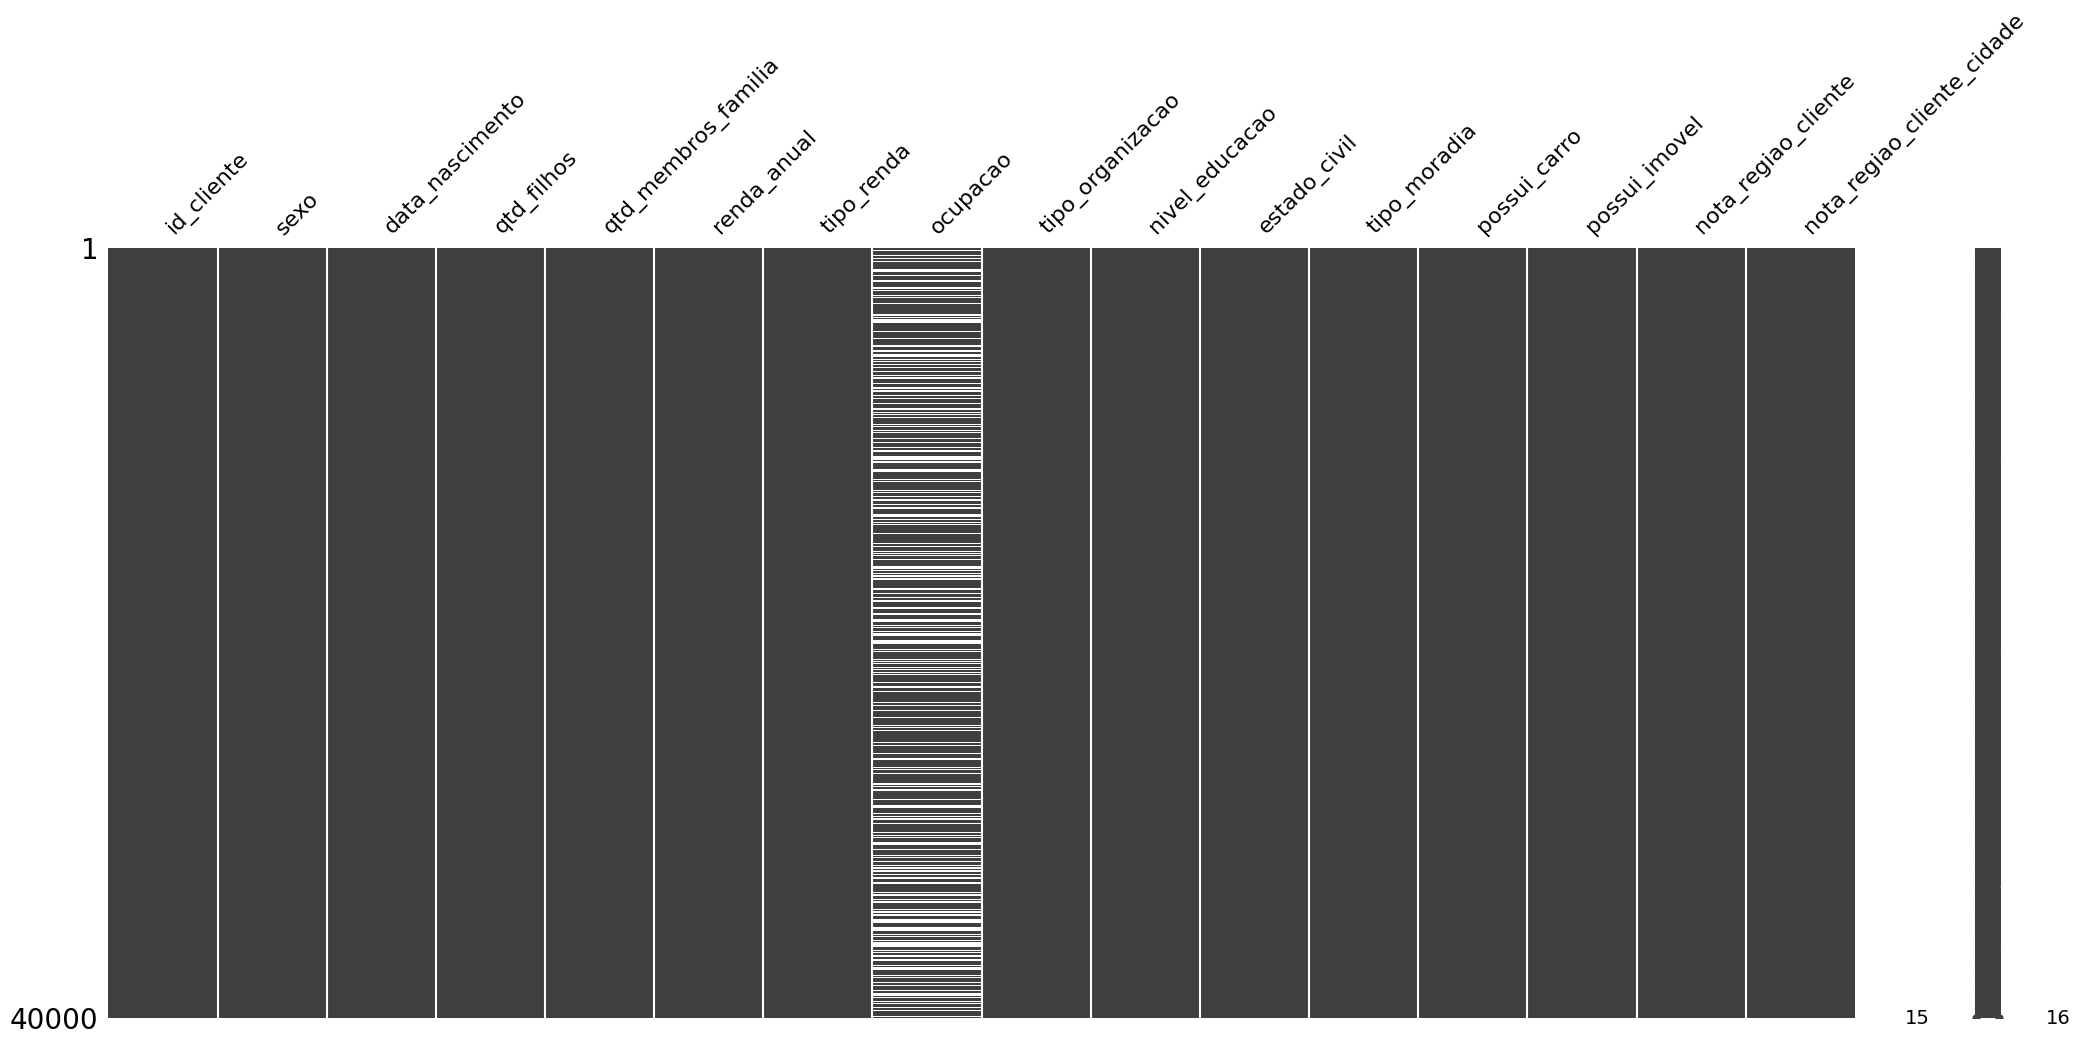

In [13]:
msno.missingno.matrix(base_cadastral)

# Análise Univariada da base cadastral

### Frequencia Distribuição de Quantidade de Filhos

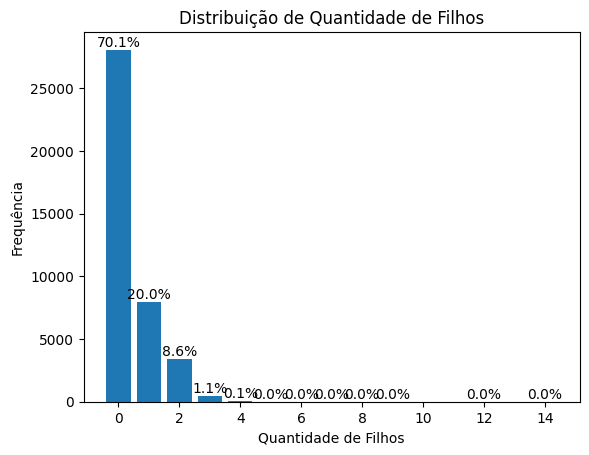

In [14]:
import matplotlib.pyplot as plt

counts = base_cadastral['qtd_filhos'].value_counts().sort_index()
percentages = counts / counts.sum() * 100

plt.figure()
bars = plt.bar(counts.index, counts.values)

for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom'
    )

plt.title("Distribuição de Quantidade de Filhos")
plt.xlabel("Quantidade de Filhos")
plt.ylabel("Frequência")
plt.show()

A maioria esmagadora não tem filhos, distribuição assimétrica à direita

### Distribuição por sexo

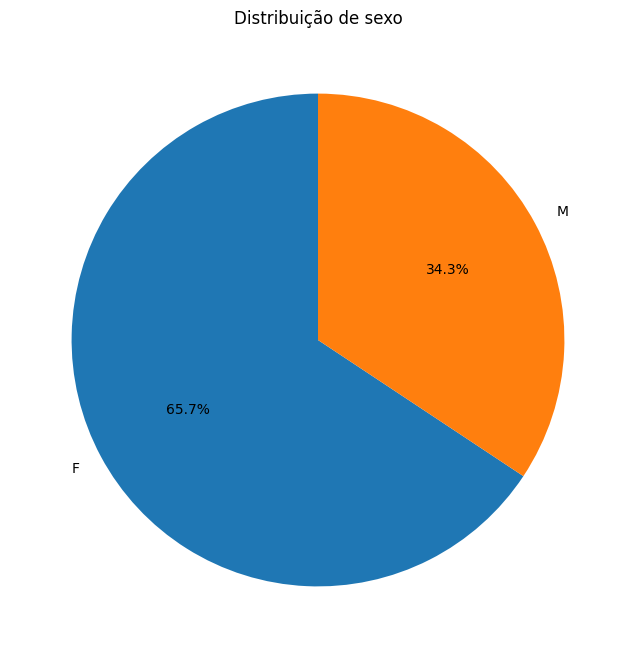

In [15]:
import matplotlib.pyplot as plt

counts = base_cadastral['sexo'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribuição de sexo")

plt.show()

A maioria é do sexo feminino, com 65.7% da base cadastral

In [16]:
import pandas as pd

base_cadastral['data_nascimento'] = pd.to_datetime(base_cadastral['data_nascimento'])

In [17]:
from datetime import datetime

current_year = datetime.now().year

base_cadastral['idade'] = current_year - base_cadastral['data_nascimento'].dt.year

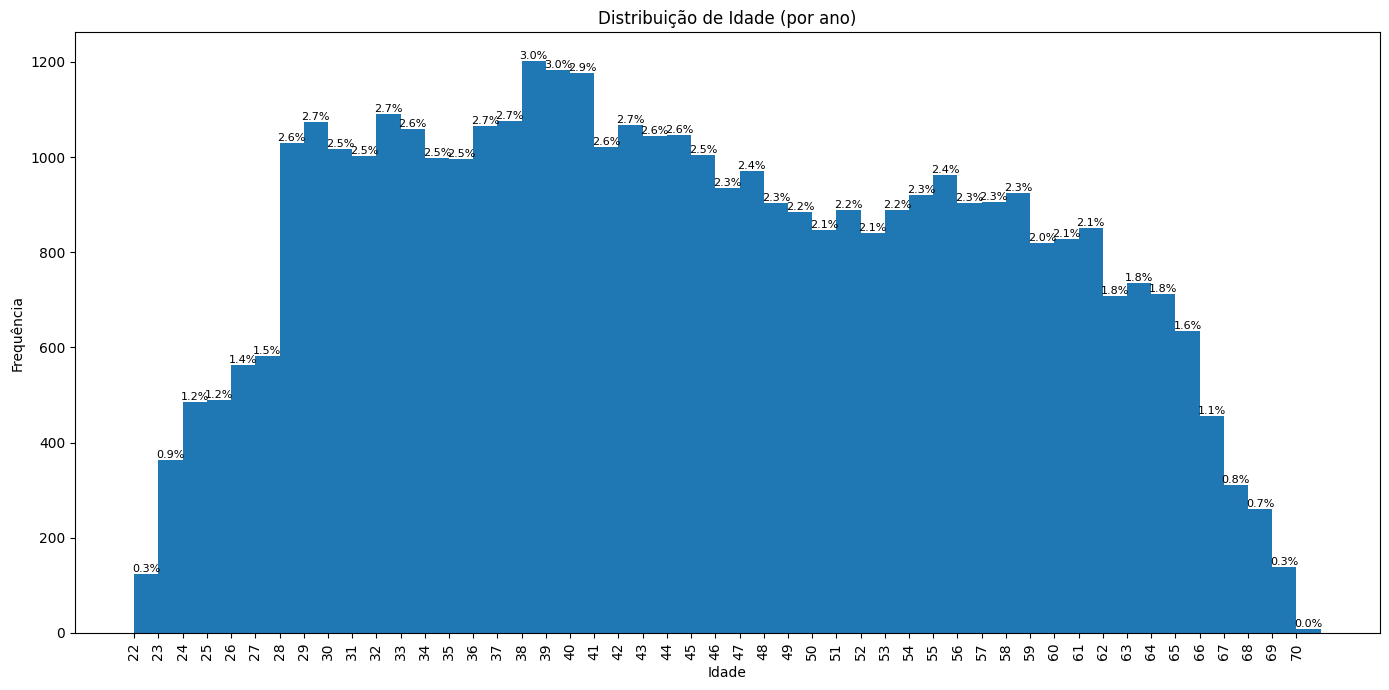

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert to datetime
base_cadastral['data_nascimento'] = pd.to_datetime(base_cadastral['data_nascimento'])

# Compute accurate age
today = pd.Timestamp.today()
base_cadastral['idade'] = (
    today.year 
    - base_cadastral['data_nascimento'].dt.year
    - (
        (today.month < base_cadastral['data_nascimento'].dt.month) |
        (
            (today.month == base_cadastral['data_nascimento'].dt.month) &
            (today.day < base_cadastral['data_nascimento'].dt.day)
        )
    )
)

# Prepare data
data = base_cadastral['idade'].dropna()

# Define bins: one per year
bins = np.arange(data.min(), data.max() + 2)

# Plot (larger figure)
plt.figure(figsize=(14, 7))

counts, bins, patches = plt.hist(data, bins=bins)

# Convert to percentages
percentages = counts / counts.sum() * 100

# Add % labels
for count, pct, patch in zip(counts, percentages, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{pct:.1f}%",
            ha='center',
            va='bottom',
            fontsize=8
        )

# Force integer ticks for each year
plt.xticks(np.arange(data.min(), data.max() + 1, 1), rotation=90)

plt.title("Distribuição de Idade (por ano)")
plt.xlabel("Idade")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [19]:
base_cadastral['idade'].describe()

count    40000.000000
mean        44.589150
std         11.985585
min         22.000000
25%         35.000000
50%         44.000000
75%         55.000000
max         70.000000
Name: idade, dtype: float64

A idade segue um distribuição próxima a normal, com valores bem distribuidos através das idades.

### Quantidade de membros da familia

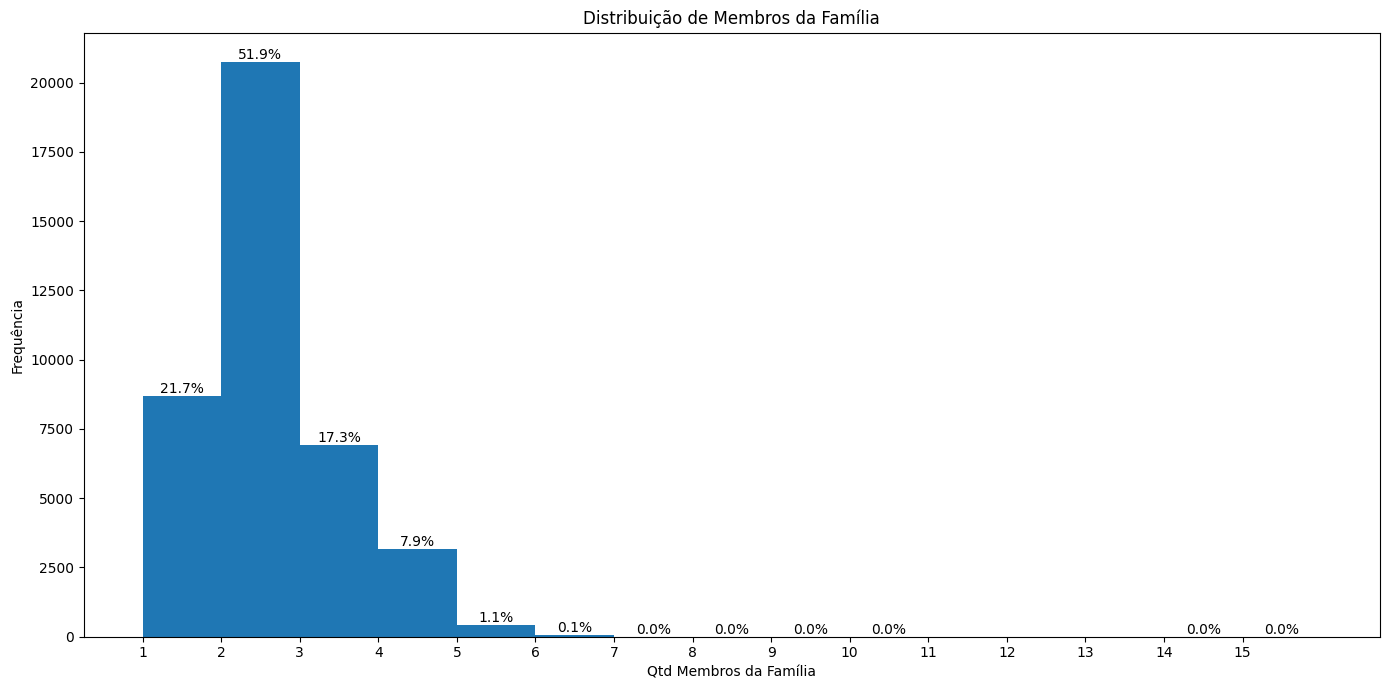

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
data = base_cadastral['qtd_membros_familia'].dropna()

# Ensure integers (in case it's float like 2.0)
data = data.astype(int)

# Define bins (one per value)
bins = np.arange(data.min(), data.max() + 2)

# Plot
plt.figure(figsize=(14, 7))

counts, bins, patches = plt.hist(data, bins=bins)

# Convert to %
percentages = counts / counts.sum() * 100

# Add % labels
for count, pct, patch in zip(counts, percentages, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{pct:.1f}%",
            ha='center',
            va='bottom',
            fontsize=10
        )

# Force integer ticks
plt.xticks(np.arange(data.min(), data.max() + 1, 1))

plt.title("Distribuição de Membros da Família")
plt.xlabel("Qtd Membros da Família")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [21]:
base_cadastral['qtd_membros_familia'].describe()

count    40000.000000
mean         2.153175
std          0.903622
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         15.000000
Name: qtd_membros_familia, dtype: float64

Temos uma distribuição assimétrica à direita, com uma concentração de 2 membros da família, representando ~52%

### Renda anual

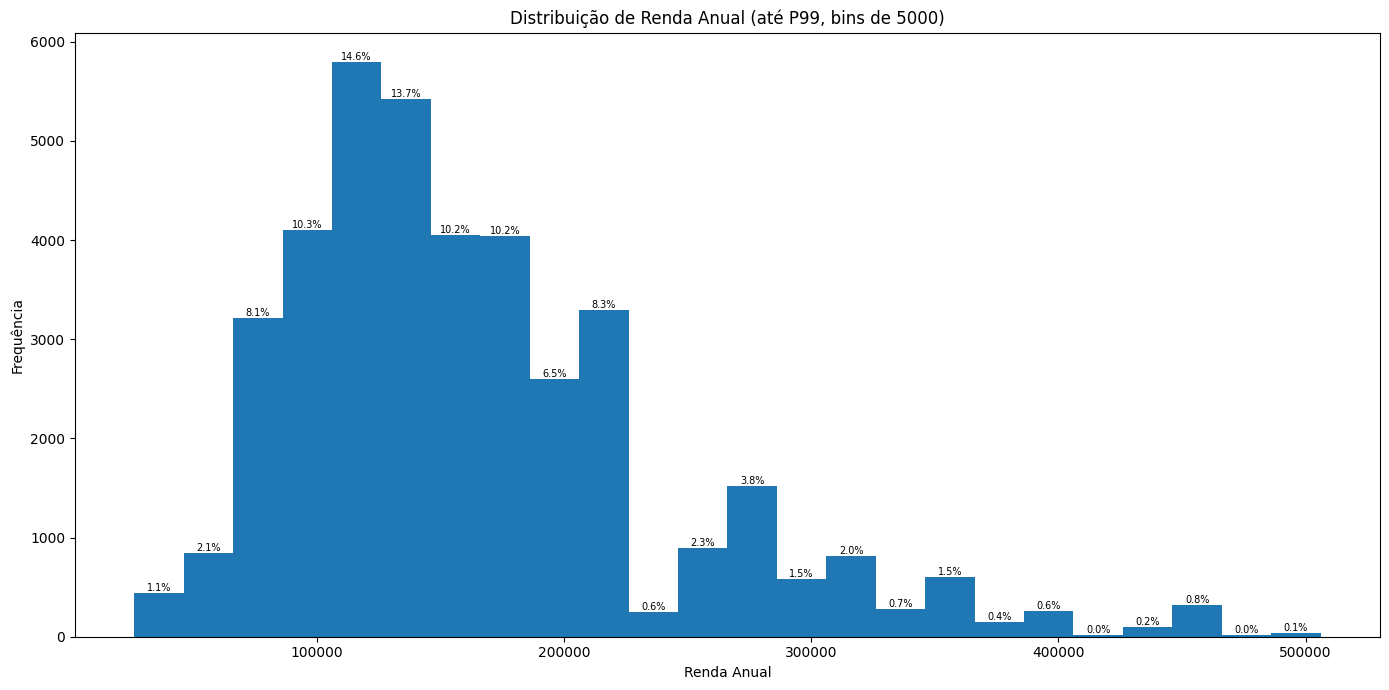

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# Original data
data = base_cadastral['renda_anual'].dropna()

# ✅ Option 1: clip at 99th percentile
p99 = data.quantile(0.99)
data_clipped = data[data <= p99]

plt.figure(figsize=(14, 7))

# Bins of 5000
bins = np.arange(data_clipped.min(), data_clipped.max() + 20000, 20000)

counts, bins, patches = plt.hist(data_clipped, bins=bins)

# Percentages
percentages = counts / counts.sum() * 100

# Add % labels
for count, pct, patch in zip(counts, percentages, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{pct:.1f}%",
            ha='center',
            va='bottom',
            fontsize=7
        )

# Fix axis formatting (no scientific notation)
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

plt.title("Distribuição de Renda Anual (até P99, bins de 5000)")
plt.xlabel("Renda Anual")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [23]:
base_cadastral['renda_anual'].describe()

count    4.000000e+04
mean     1.728539e+05
std      6.025102e+05
min      2.610000e+04
25%      1.125000e+05
50%      1.485000e+05
75%      2.025000e+05
max      1.170000e+08
Name: renda_anual, dtype: float64

Temos uma distribuição de renda assimétrica à direita, com 75% com uma renda de até R$ 202500

### Tipo de renda

In [24]:
base_cadastral['tipo_renda'].value_counts()

tipo_renda
Working                 20502
Commercial associate     9251
Pensioner                7380
State servant            2858
Unemployed                  3
Maternity leave             3
Student                     2
Businessman                 1
Name: count, dtype: int64

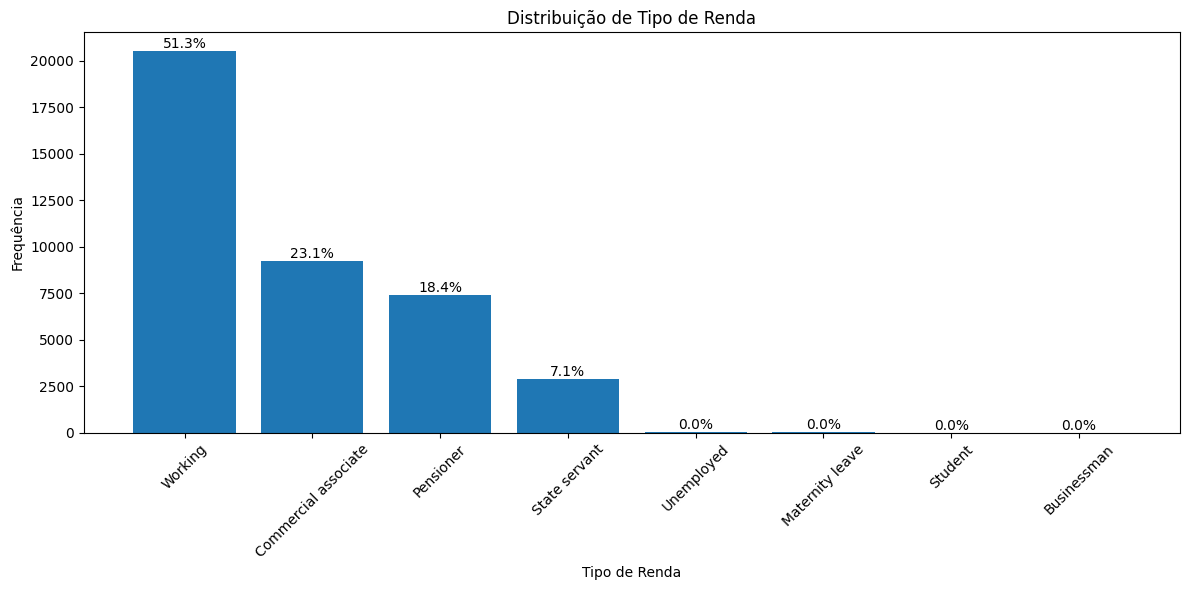

In [25]:
import matplotlib.pyplot as plt

counts = base_cadastral['tipo_renda'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(12, 6))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom'
    )

plt.title("Distribuição de Tipo de Renda")
plt.xlabel("Tipo de Renda")
plt.ylabel("Frequência")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Temos uma distribuição assimétrica à direita, com a maioria esmagadora na classe Working

# Ocuopação

In [26]:
base_cadastral['ocupacao'].isnull().sum()

np.int64(12676)

Temos 12676 ocupação não informados, posteriormente iremos usar uma flag distinta para não informado

In [27]:
base_cadastral['ocupacao'] = base_cadastral['ocupacao'].fillna('Unknown')

In [28]:
base_cadastral['ocupacao'].value_counts()

ocupacao
Unknown                  12676
Laborers                  7083
Sales staff               4190
Core staff                3501
Managers                  2763
Drivers                   2399
High skill tech staff     1532
Accountants               1261
Medicine staff            1086
Security staff             915
Cooking staff              753
Cleaning staff             585
Private service staff      360
Low-skill Laborers         251
Waiters/barmen staff       200
Secretaries                182
Realty agents              104
IT staff                    85
HR staff                    74
Name: count, dtype: int64

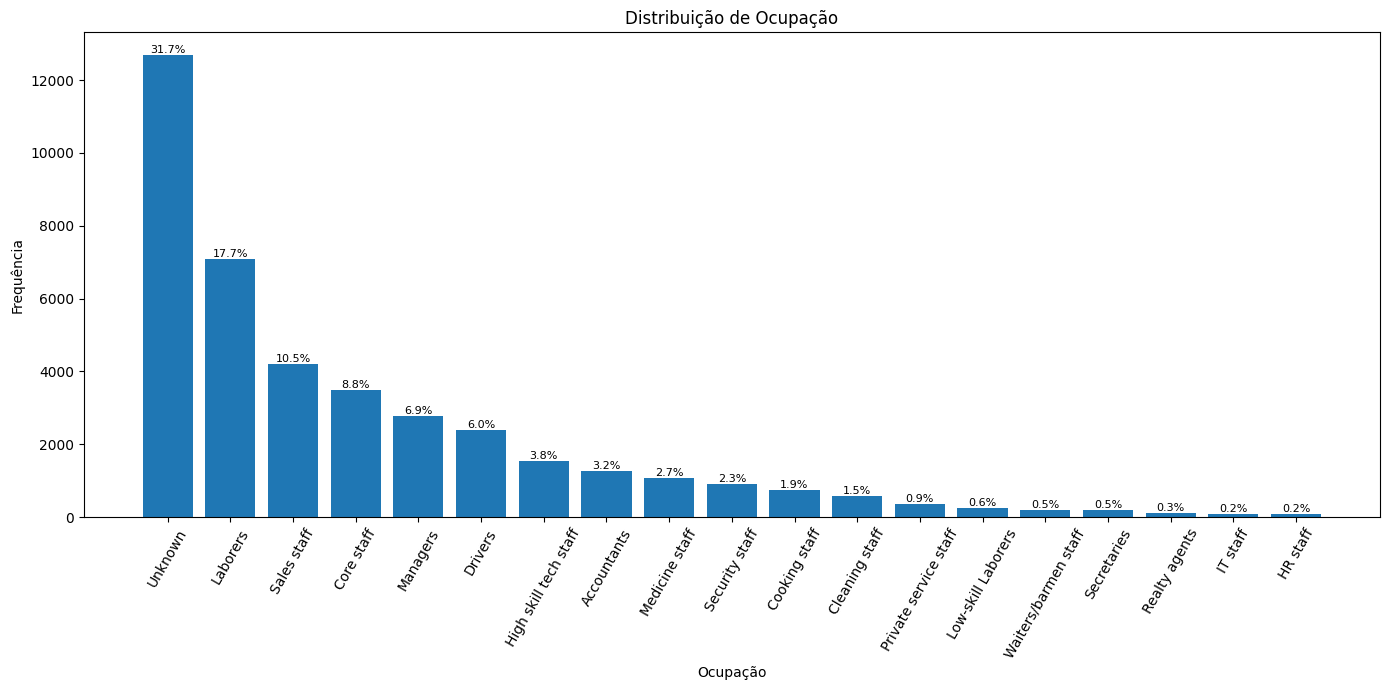

In [29]:
import matplotlib.pyplot as plt

counts = base_cadastral['ocupacao'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de Ocupação")
plt.xlabel("Ocupação")
plt.ylabel("Frequência")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

Temos uma distribuição assimétrica a direita, e a maioria dos clientes não informam sua ocupação

### Tipo de organização

In [30]:
base_cadastral['tipo_organizacao'].value_counts()

tipo_organizacao
Business Entity Type 3    8840
XNA                       7383
Self-employed             5054
Other                     2249
Medicine                  1387
Government                1319
Business Entity Type 2    1313
School                    1162
Trade: type 7             1024
Construction               872
Kindergarten               858
Business Entity Type 1     798
Transport: type 4          686
Trade: type 3              453
Security                   425
Industry: type 9           392
Industry: type 3           385
Housing                    373
Industry: type 11          340
Military                   320
Bank                       308
Police                     301
Transport: type 2          300
Postal                     290
Agriculture                285
Trade: type 2              254
Security Ministries        240
Restaurant                 235
Services                   211
University                 161
Transport: type 3          157
Hotel                 

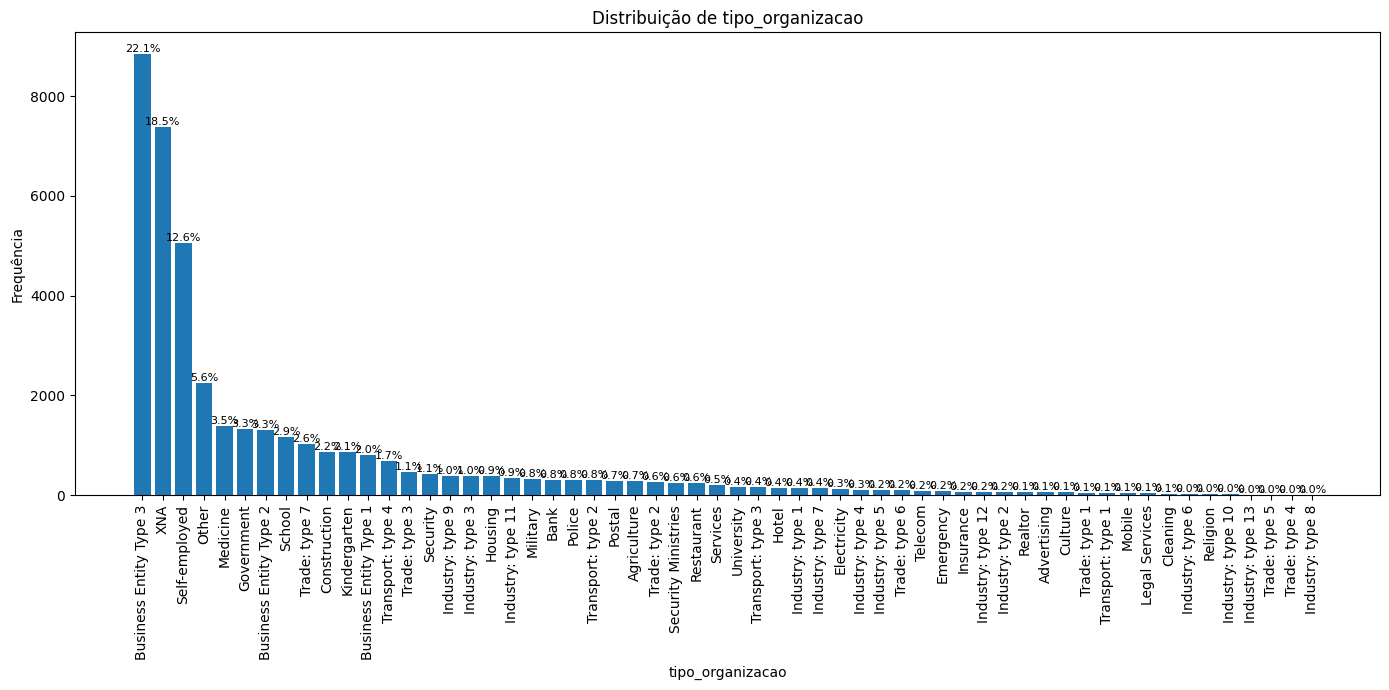

In [31]:
import matplotlib.pyplot as plt

counts = base_cadastral['tipo_organizacao'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))
bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de tipo_organizacao")
plt.xlabel("tipo_organizacao")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Temos uma distribuição assimétrica a direita, com a maioria esmagadora trabalhando em Business Entity Type 3 e XNA e Self-employed


### Nivel de educação alcançado

In [32]:
base_cadastral['nivel_educacao'].value_counts()

nivel_educacao
Secondary / secondary special    28513
Higher education                  9633
Incomplete higher                 1366
Lower secondary                    463
Academic degree                     25
Name: count, dtype: int64

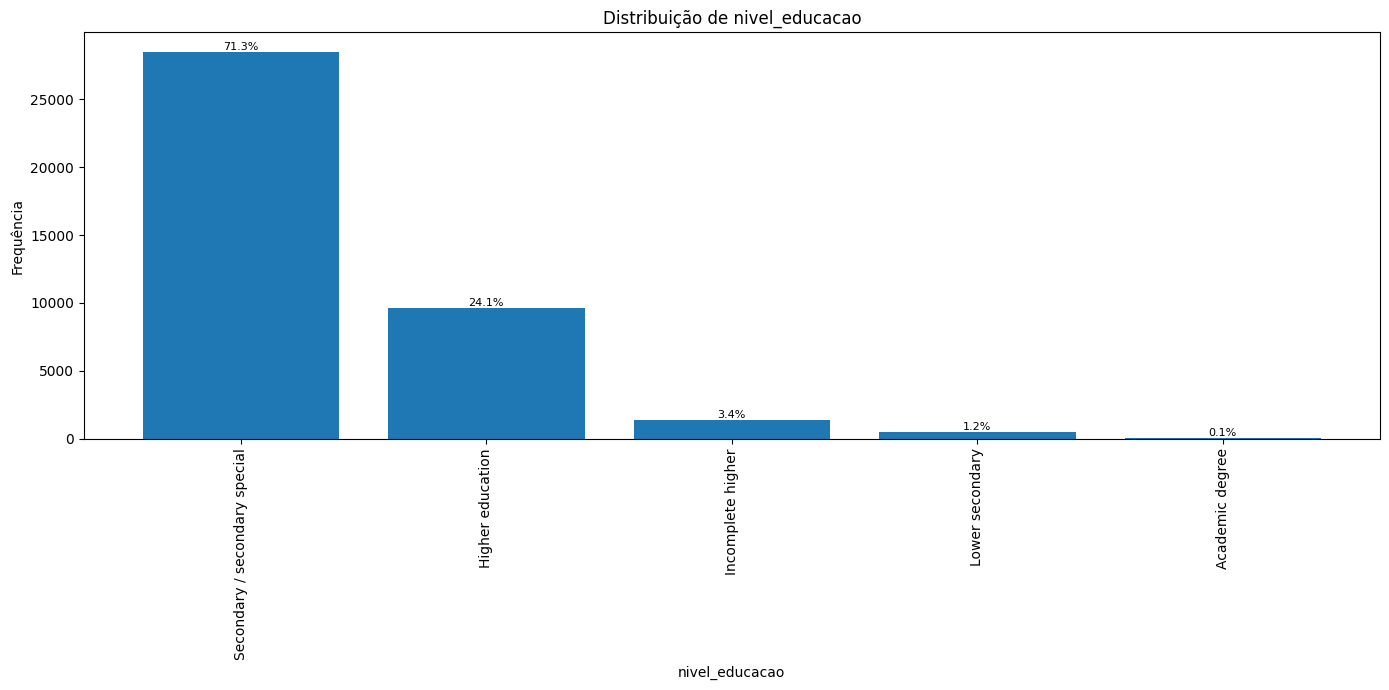

In [33]:
import matplotlib.pyplot as plt

counts = base_cadastral['nivel_educacao'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de nivel_educacao")
plt.xlabel("nivel_educacao")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Temos uma distribuiçao assimétrica à direita 

### Estado Civil

In [34]:
base_cadastral['estado_civil'].value_counts()

estado_civil
Married                 25726
Single / not married     5824
Civil marriage           3872
Separated                2551
Widow                    2027
Name: count, dtype: int64

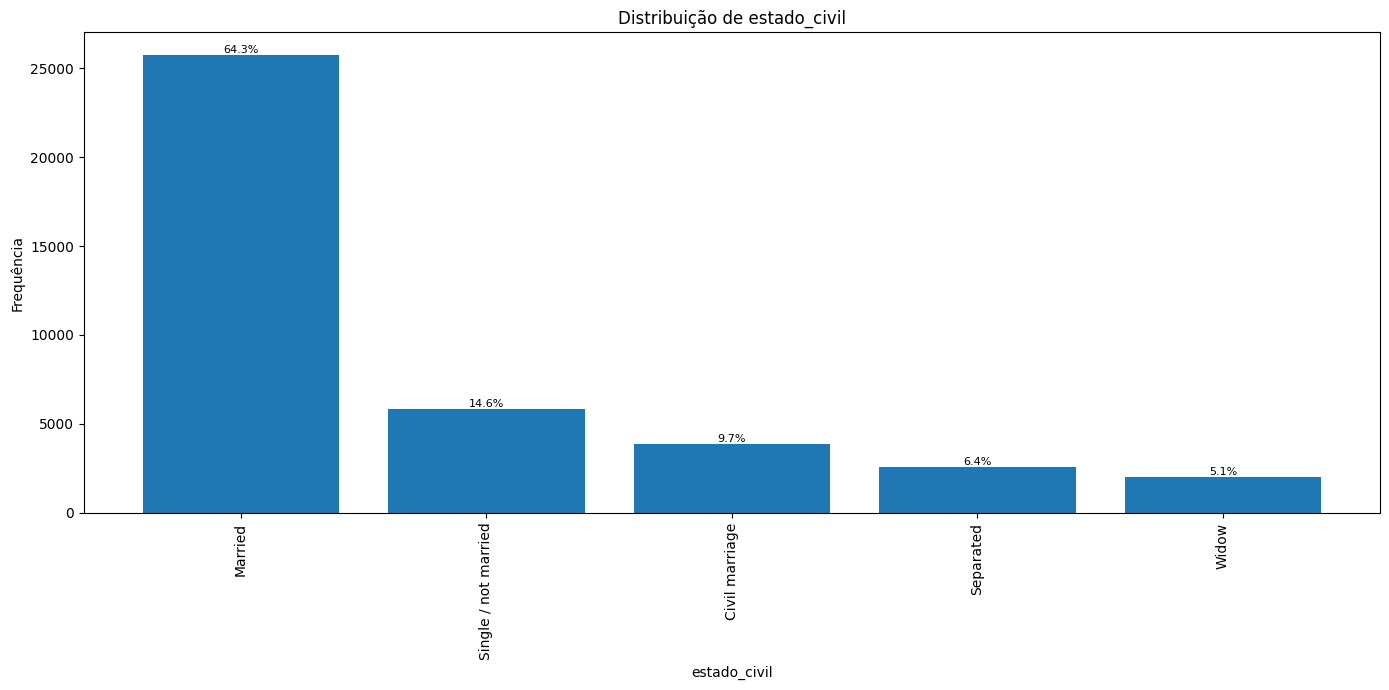

In [35]:
import matplotlib.pyplot as plt

counts = base_cadastral['estado_civil'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de estado_civil")
plt.xlabel("estado_civil")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Temos uma distribuição assimétrica à direita com a maioria sendo casados.

### Tipo moradia

In [36]:
base_cadastral["tipo_moradia"].value_counts()

tipo_moradia
House / apartment      35671
With parents            1872
Municipal apartment     1399
Rented apartment         616
Office apartment         315
Co-op apartment          127
Name: count, dtype: int64

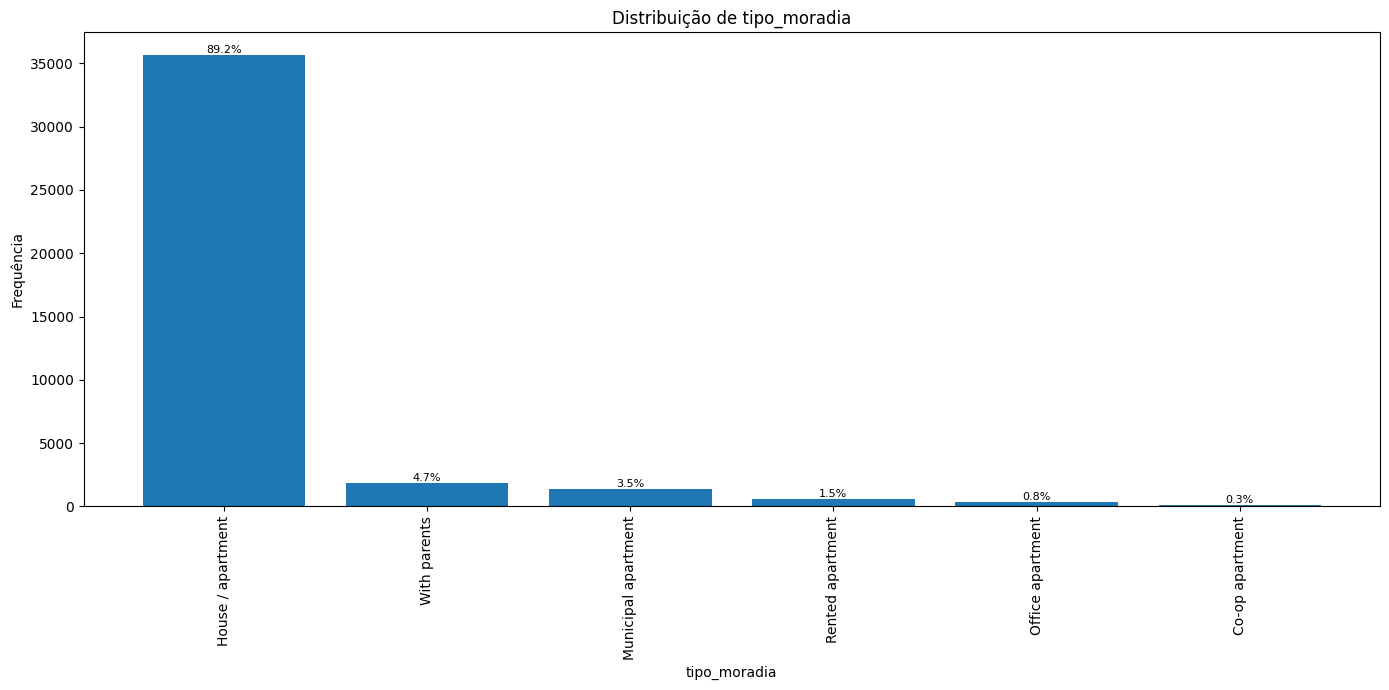

In [37]:
import matplotlib.pyplot as plt

counts = base_cadastral['tipo_moradia'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de tipo_moradia")
plt.xlabel("tipo_moradia")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Temos uma distribuição assimétrica a direita com a maioria esmagadora morando em casa ou apartamento

### Possui Carro?

In [38]:
base_cadastral['possui_carro'].value_counts()

possui_carro
N    26375
Y    13625
Name: count, dtype: int64

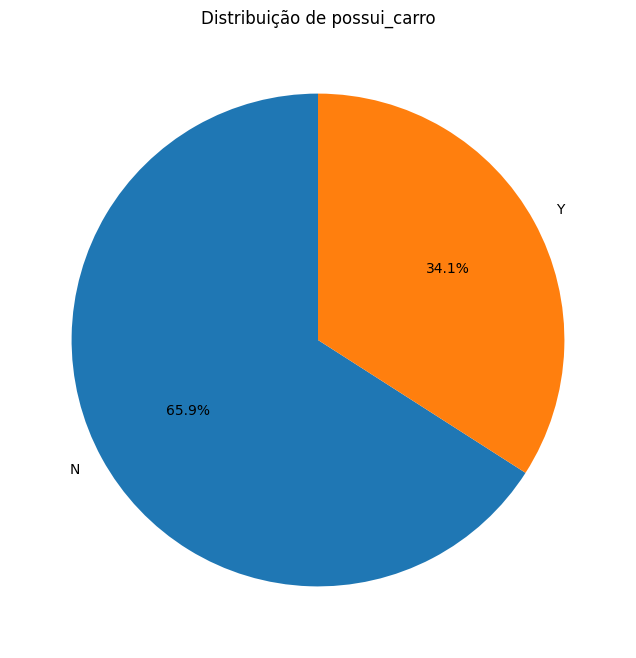

In [39]:
import matplotlib.pyplot as plt

counts = base_cadastral['possui_carro'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribuição de possui_carro")

plt.show()

A maioria NÃO possui carro

### Possui Imovel

In [40]:
base_cadastral['possui_imovel'].value_counts()

possui_imovel
Y    27686
N    12314
Name: count, dtype: int64

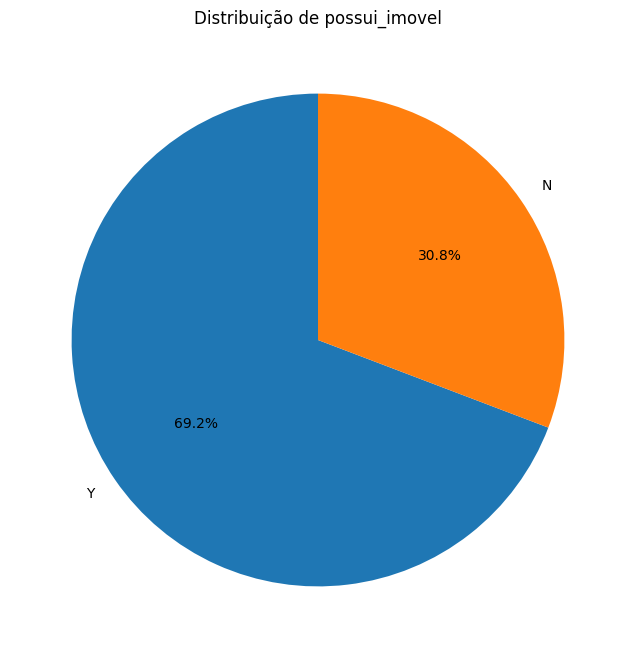

In [41]:
import matplotlib.pyplot as plt

counts = base_cadastral['possui_imovel'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribuição de possui_imovel")

plt.show()

A maioria possui imovel

### Nota regiao cliente

In [42]:
base_cadastral['nota_regiao_cliente'].describe()

count    40000.000000
mean         2.051475
std          0.509295
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: nota_regiao_cliente, dtype: float64

In [43]:
base_cadastral['nota_regiao_cliente'].unique()

array([2, 3, 1])

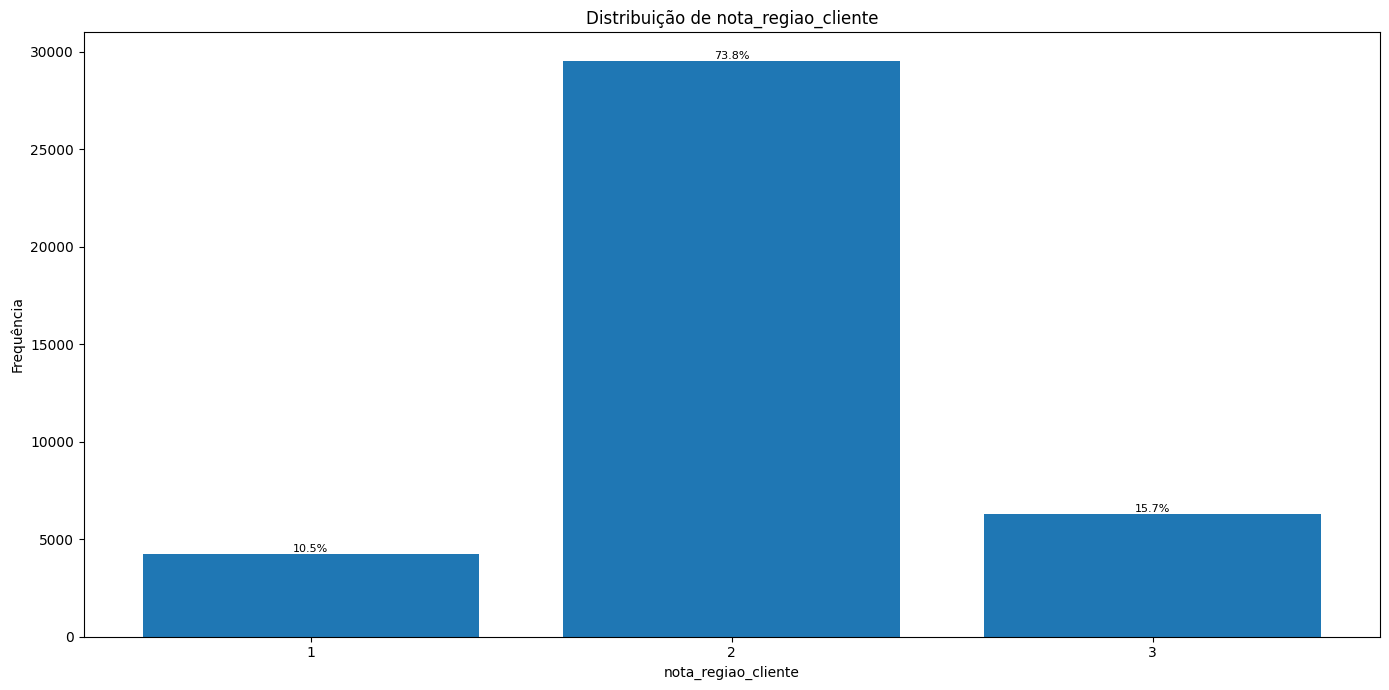

In [44]:
import matplotlib.pyplot as plt

# Force order
counts = base_cadastral['nota_regiao_cliente'].value_counts().sort_index()

percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de nota_regiao_cliente")
plt.xlabel("nota_regiao_cliente")
plt.ylabel("Frequência")

# ✅ Force ticks exactly at 1, 2, 3
plt.xticks([1, 2, 3])

plt.tight_layout()
plt.show()

### Nota regiao cliente cidade

In [45]:
base_cadastral['nota_regiao_cliente_cidade'].describe()

count    40000.000000
mean         2.029375
std          0.503158
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: nota_regiao_cliente_cidade, dtype: float64

In [46]:
base_cadastral['nota_regiao_cliente_cidade'].unique()

array([2, 3, 1])

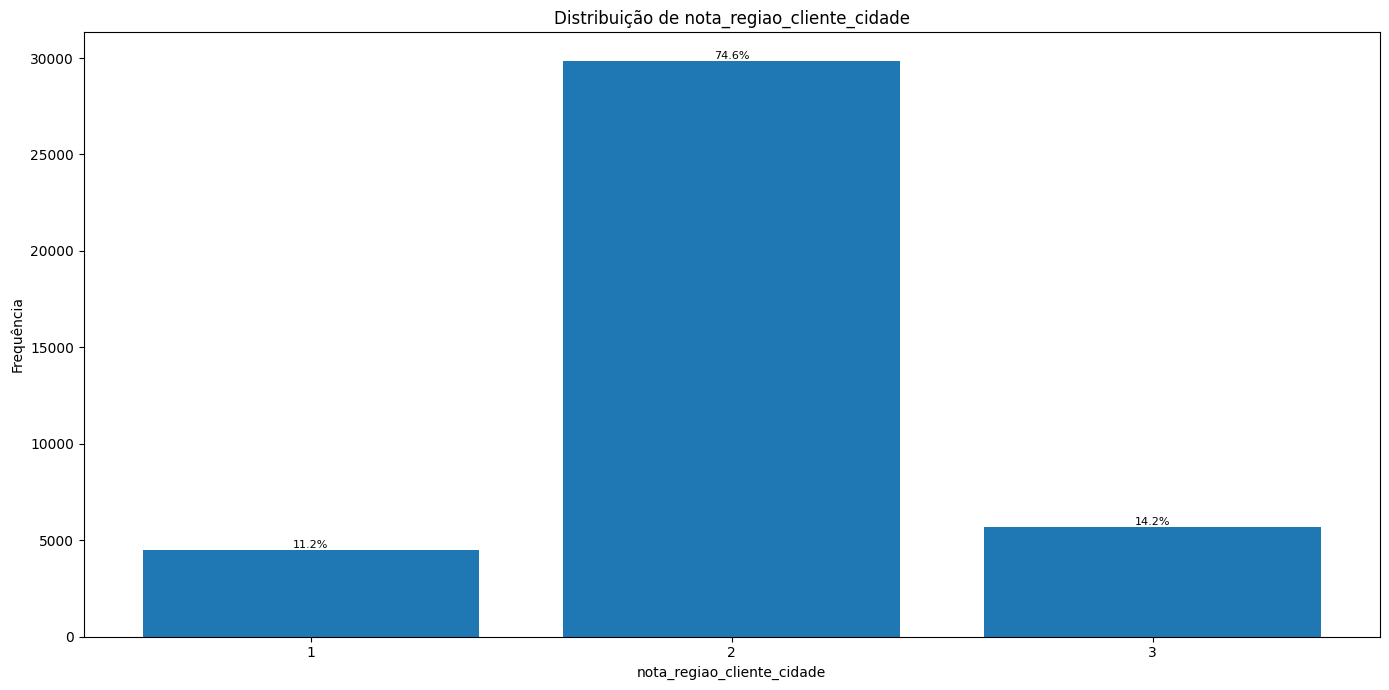

In [47]:
import matplotlib.pyplot as plt

# Force order
counts = base_cadastral['nota_regiao_cliente_cidade'].value_counts().sort_index()

percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de nota_regiao_cliente_cidade")
plt.xlabel("nota_regiao_cliente_cidade")
plt.ylabel("Frequência")

# ✅ Force ticks exactly at 1, 2, 3
plt.xticks([1, 2, 3])

plt.tight_layout()
plt.show()

# Analise univarida de historico_emprestimos

In [48]:
historico_emprestimos.dtypes

id_contrato                           int64
id_cliente                            int64
tipo_contrato                           str
status_contrato                         str
data_decisao                            str
data_liberacao                          str
data_primeiro_vencimento                str
data_ultimo_vencimento_original         str
data_ultimo_vencimento                  str
data_encerramento                       str
valor_solicitado                    float64
valor_credito                       float64
valor_bem                           float64
valor_parcela                       float64
valor_entrada                       float64
percentual_entrada                  float64
qtd_parcelas_planejadas             float64
taxa_juros_padrao                   float64
taxa_juros_promocional              float64
tipo_pagamento                          str
finalidade_emprestimo                   str
tipo_cliente                            str
faixa_rendimento                

In [49]:
# Porcentagem de itens nulos
(historico_emprestimos.isnull().sum()/historico_emprestimos.shape[0] * 100).round(2)

id_contrato                          0.00
id_cliente                           0.00
tipo_contrato                        0.00
status_contrato                      0.00
data_decisao                         0.00
data_liberacao                      96.20
data_primeiro_vencimento            42.67
data_ultimo_vencimento_original     45.88
data_ultimo_vencimento              53.03
data_encerramento                   53.94
valor_solicitado                     0.00
valor_credito                        0.00
valor_bem                           23.24
valor_parcela                       22.35
valor_entrada                       53.60
percentual_entrada                  53.60
qtd_parcelas_planejadas             22.35
taxa_juros_padrao                   99.66
taxa_juros_promocional              99.66
tipo_pagamento                       0.00
finalidade_emprestimo                0.00
tipo_cliente                         0.00
faixa_rendimento                     0.00
tipo_portfolio                    

<Axes: >

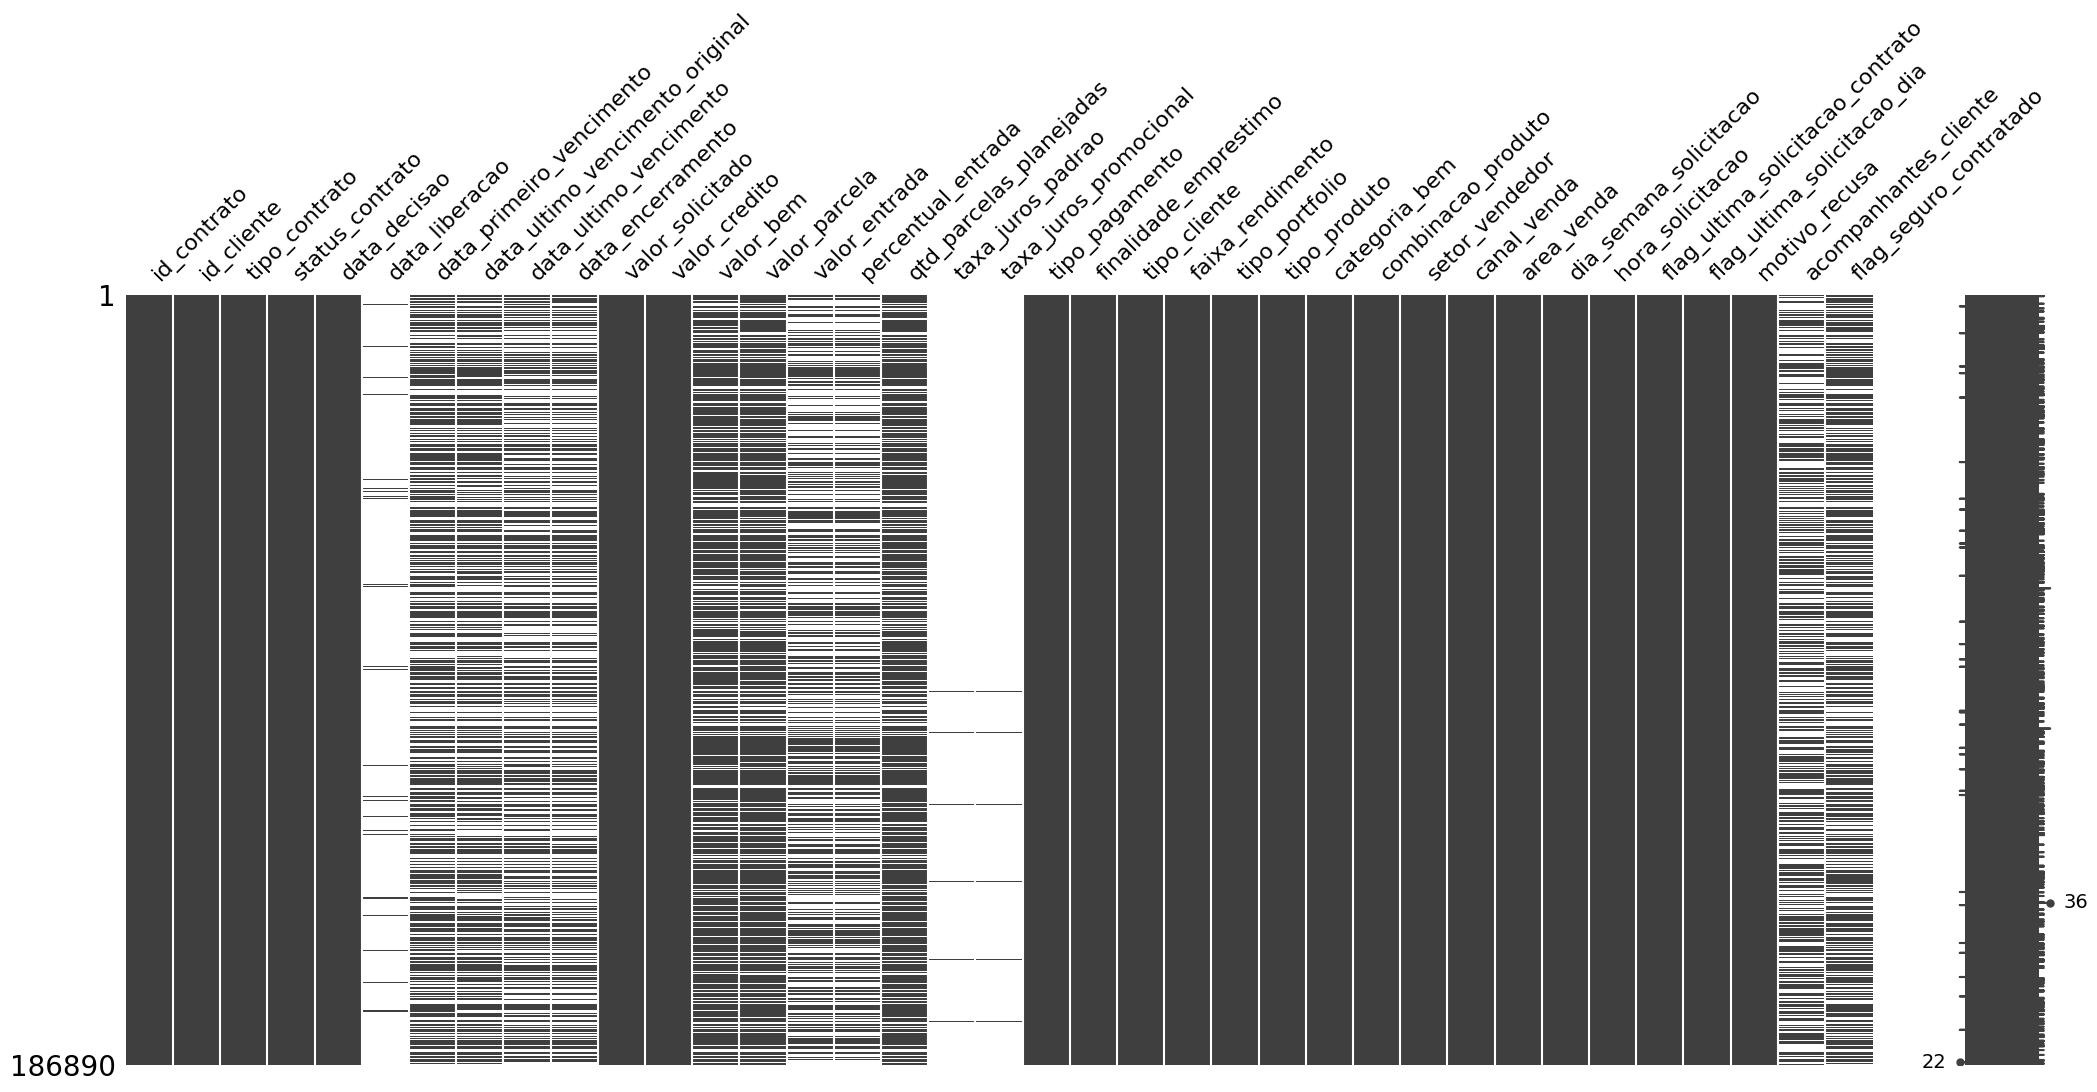

In [50]:
msno.missingno.matrix(historico_emprestimos)

* historico_emprestimos apresenda dados bem esparsos, vou retirar colunas onde a taxa de não inputados >95% missingness (noise) taxa_juros_padrao, taxa juros promocional
* colunas onde há data leakage por informar o resultado do emprestimo (favorável ou nao): status_contrato, motivo_recusa. 
* data_liberacao, data_encerramento, data_ultimo_vencimento (essas acontecem pós aprovação) leakage futuro
* lag_ultima_solicitacao_contrato, flag_ultima_solicitacao_dia redundantes

In [51]:
drop_cols = [
    "status_contrato",
    "motivo_recusa",
    "data_liberacao",
    "data_encerramento",
    "data_ultimo_vencimento",
    "taxa_juros_padrao",
    "taxa_juros_promocional",
    "flag_ultima_solicitacao_contrato",
    "flag_ultima_solicitacao_dia"
]

In [52]:
historico_emprestimos.drop(columns=drop_cols, inplace=True, axis=0)
(historico_emprestimos.isnull().sum()/historico_emprestimos.shape[0] * 100).round(2)

id_contrato                         0.00
id_cliente                          0.00
tipo_contrato                       0.00
data_decisao                        0.00
data_primeiro_vencimento           42.67
data_ultimo_vencimento_original    45.88
valor_solicitado                    0.00
valor_credito                       0.00
valor_bem                          23.24
valor_parcela                      22.35
valor_entrada                      53.60
percentual_entrada                 53.60
qtd_parcelas_planejadas            22.35
tipo_pagamento                      0.00
finalidade_emprestimo               0.00
tipo_cliente                        0.00
faixa_rendimento                    0.00
tipo_portfolio                      0.00
tipo_produto                        0.00
categoria_bem                       0.00
combinacao_produto                  0.02
setor_vendedor                      0.00
canal_venda                         0.00
area_venda                          0.00
dia_semana_solic

In [53]:
print(f"Numero de rows e features por contrato: {historico_emprestimos.shape}")
print(f"Numero de contratos unicos: {historico_emprestimos['id_contrato'].nunique()}")
print(f"Numero de contratos total: {historico_emprestimos['id_contrato'].count()}")
print(f"Numero de clientes com contratos: {historico_emprestimos['id_cliente'].nunique()}")

Numero de rows e features por contrato: (186890, 28)
Numero de contratos unicos: 186890
Numero de contratos total: 186890
Numero de clientes com contratos: 37952


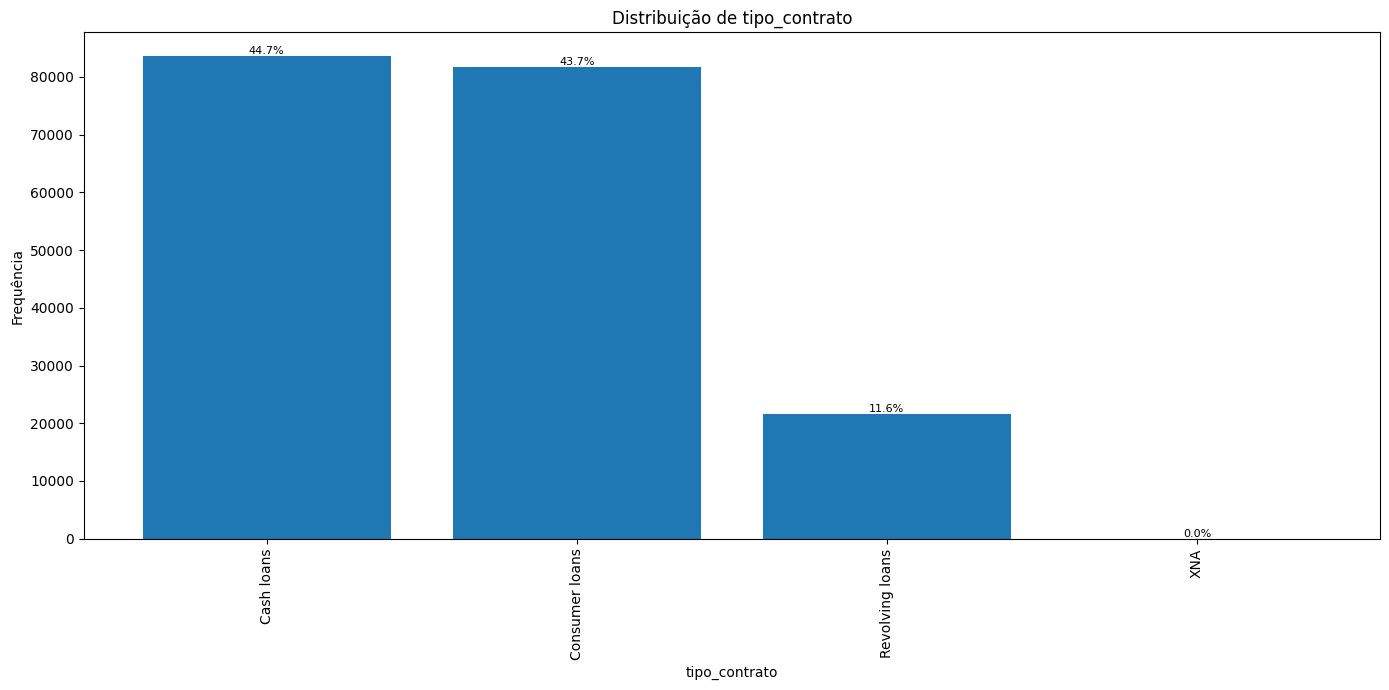

In [54]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['tipo_contrato'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de tipo_contrato")
plt.xlabel("tipo_contrato")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Os contratos são mais concentrados em Cash loans e Customer loans, Revolving loans com 11.6% e XNA

# Data decisao do emprestimo

In [55]:
historico_emprestimos['data_decisao'] = pd.to_datetime(
    historico_emprestimos['data_decisao'],
    errors='coerce'  # important: invalid dates → NaT
)

In [56]:
historico_emprestimos['data_decisao'].isna().mean()

np.float64(0.0)

<Axes: title={'center': 'Data decisão'}, xlabel='data_decisao'>

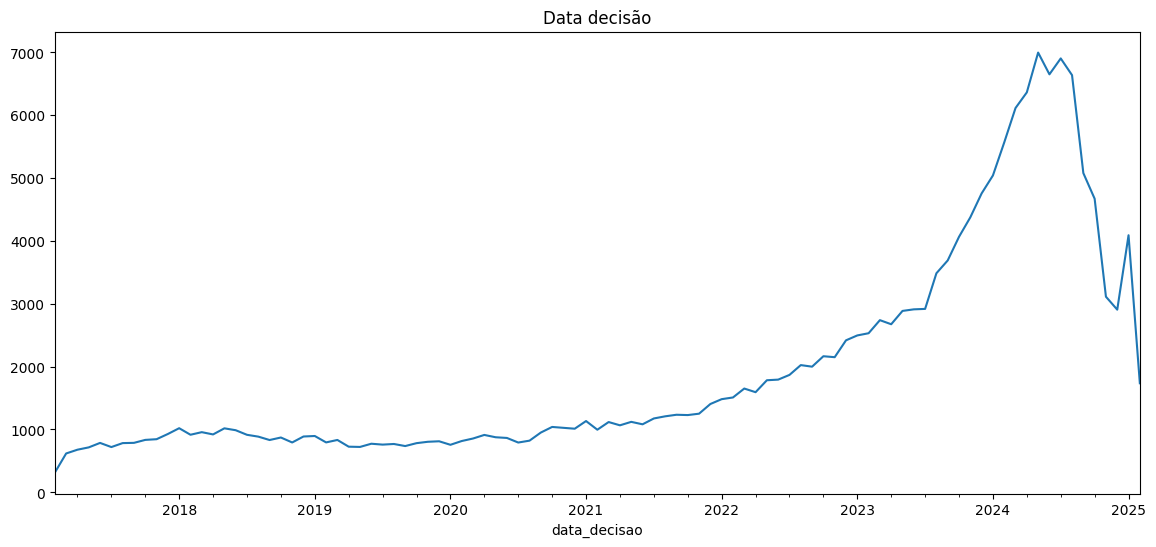

In [57]:
monthly = (
    historico_emprestimos
    .set_index('data_decisao')
    .resample('ME')
    .size()
)

monthly.plot(figsize=(14,6), title='Data decisão')

# Data primeiro vencimento

In [58]:
historico_emprestimos['data_primeiro_vencimento'] = pd.to_datetime(
    historico_emprestimos['data_primeiro_vencimento'],
    errors='coerce'
)

In [59]:
historico_emprestimos['data_primeiro_vencimento'].isna().mean()

np.float64(0.4266948472363422)

43% missing!!! Provavelmente contratos ainda não aprovados, contratos cancelados, provavelmente não é MNAR(Missing Not At Random). Na fase de feature engineering podemos comparar alguma data que tenha indicios de que o contrato foi firmado

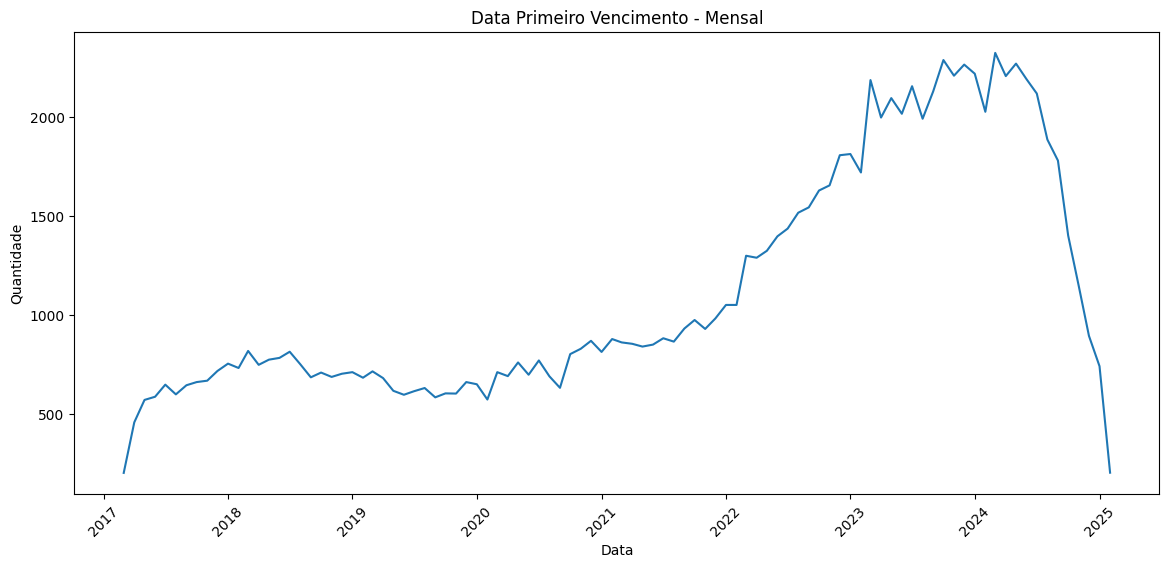

In [60]:
import matplotlib.pyplot as plt

df = historico_emprestimos.dropna(subset=['data_primeiro_vencimento'])

ts = df.set_index('data_primeiro_vencimento').resample('MS').size()

plt.figure(figsize=(14,6))
plt.plot(ts.index, ts.values)
plt.title('Data Primeiro Vencimento - Mensal')
plt.xlabel('Data')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()


# Data ultimo vencimento original

In [61]:
historico_emprestimos['data_ultimo_vencimento_original'] = pd.to_datetime(
    historico_emprestimos['data_ultimo_vencimento_original'],
    errors='coerce'
)

In [62]:
historico_emprestimos['data_ultimo_vencimento_original'].isna().mean()

np.float64(0.458809995184333)

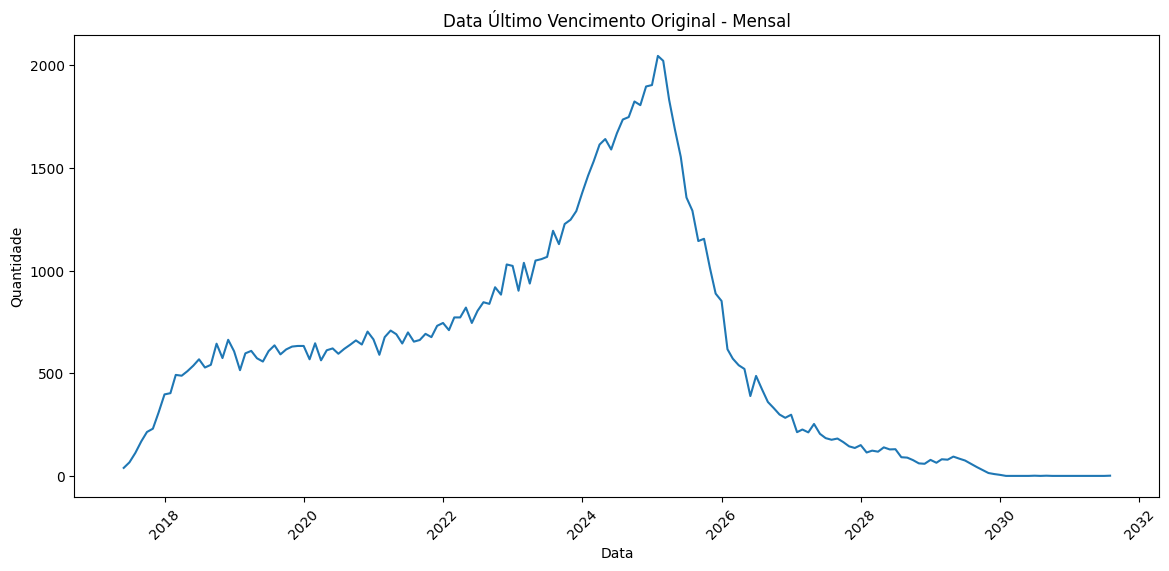

In [63]:
import matplotlib.pyplot as plt

df = historico_emprestimos.dropna(subset=['data_ultimo_vencimento_original'])

ts = df.set_index('data_ultimo_vencimento_original').resample('MS').size()

plt.figure(figsize=(14,6))
plt.plot(ts.index, ts.values)
plt.title('Data Último Vencimento Original - Mensal')
plt.xlabel('Data')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

In [64]:
historico_emprestimos[['data_decisao', 'data_ultimo_vencimento_original']].head()

,data_decisao,data_ultimo_vencimento_original
0,2024-08-29,2027-08-14
1,2022-10-11,2024-09-30
2,2023-04-08,2025-09-24
3,2024-02-08,2025-02-02
4,2024-09-06,NaT


In [65]:
(
    historico_emprestimos['data_ultimo_vencimento_original'] <
    historico_emprestimos['data_decisao']
).mean()

np.float64(0.0)

Não já casos em qhe a data final é antes da data de decisão, então não há risco de data leakage!

# Valor solicitado

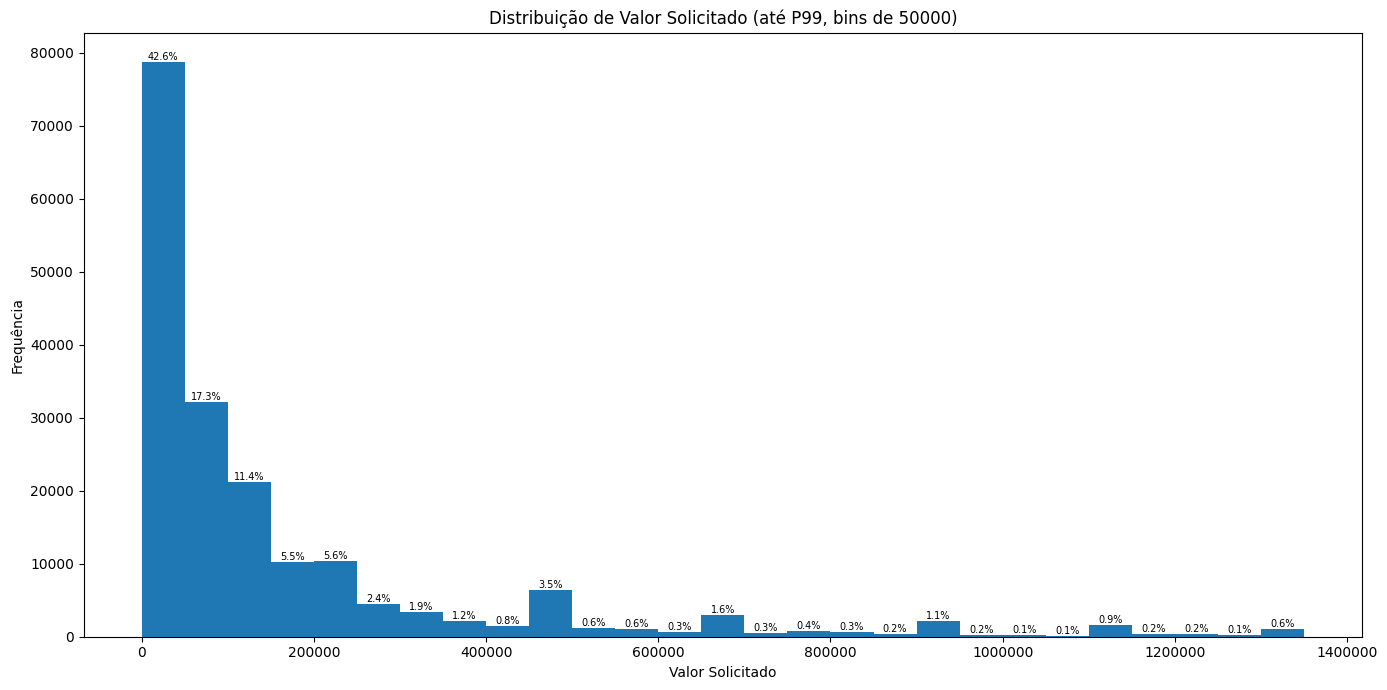

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# Original data
data = historico_emprestimos['valor_solicitado']

# ✅ Option 1: clip at 99th percentile
p99 = data.quantile(0.99)
data_clipped = data[data <= p99]

plt.figure(figsize=(14, 7))

# Bins of 5000
bins = np.arange(data_clipped.min(), data_clipped.max() + 50000, 50000)

counts, bins, patches = plt.hist(data_clipped, bins=bins)

# Percentages
percentages = counts / counts.sum() * 100

# Add % labels
for count, pct, patch in zip(counts, percentages, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{pct:.1f}%",
            ha='center',
            va='bottom',
            fontsize=7
        )

# Fix axis formatting (no scientific notation)
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

plt.title("Distribuição de Valor Solicitado (até P99, bins de 50000)")
plt.xlabel("Valor Solicitado")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [67]:
historico_emprestimos['valor_solicitado'].describe()

count    1.868900e+05
mean     1.740103e+05
std      2.903515e+05
min      0.000000e+00
25%      1.813500e+04
50%      7.075800e+04
75%      1.800000e+05
max      3.825000e+06
Name: valor_solicitado, dtype: float64

# Valor credito

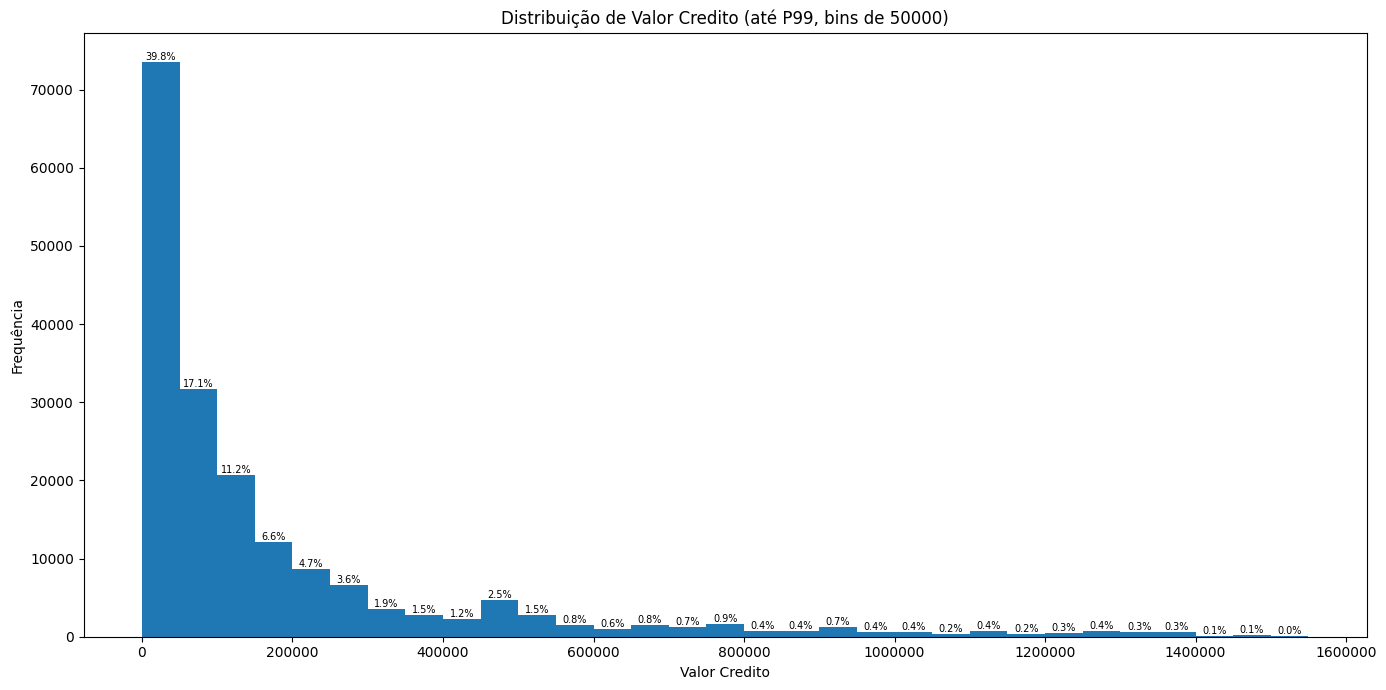

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# Original data
data = historico_emprestimos['valor_credito']

# ✅ Option 1: clip at 99th percentile
p99 = data.quantile(0.99)
data_clipped = data[data <= p99]

plt.figure(figsize=(14, 7))

# Bins of 5000
bins = np.arange(data_clipped.min(), data_clipped.max() + 50000, 50000)

counts, bins, patches = plt.hist(data_clipped, bins=bins)

# Percentages
percentages = counts / counts.sum() * 100

# Add % labels
for count, pct, patch in zip(counts, percentages, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{pct:.1f}%",
            ha='center',
            va='bottom',
            fontsize=7
        )

# Fix axis formatting (no scientific notation)
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

plt.title("Distribuição de Valor Credito (até P99, bins de 50000)")
plt.xlabel("Valor Credito")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [69]:
historico_emprestimos['valor_credito'].describe()

count    1.868900e+05
mean     1.947094e+05
std      3.161218e+05
min      0.000000e+00
25%      2.360700e+04
50%      8.009100e+04
75%      2.156400e+05
max      3.749054e+06
Name: valor_credito, dtype: float64

### Valor Bem

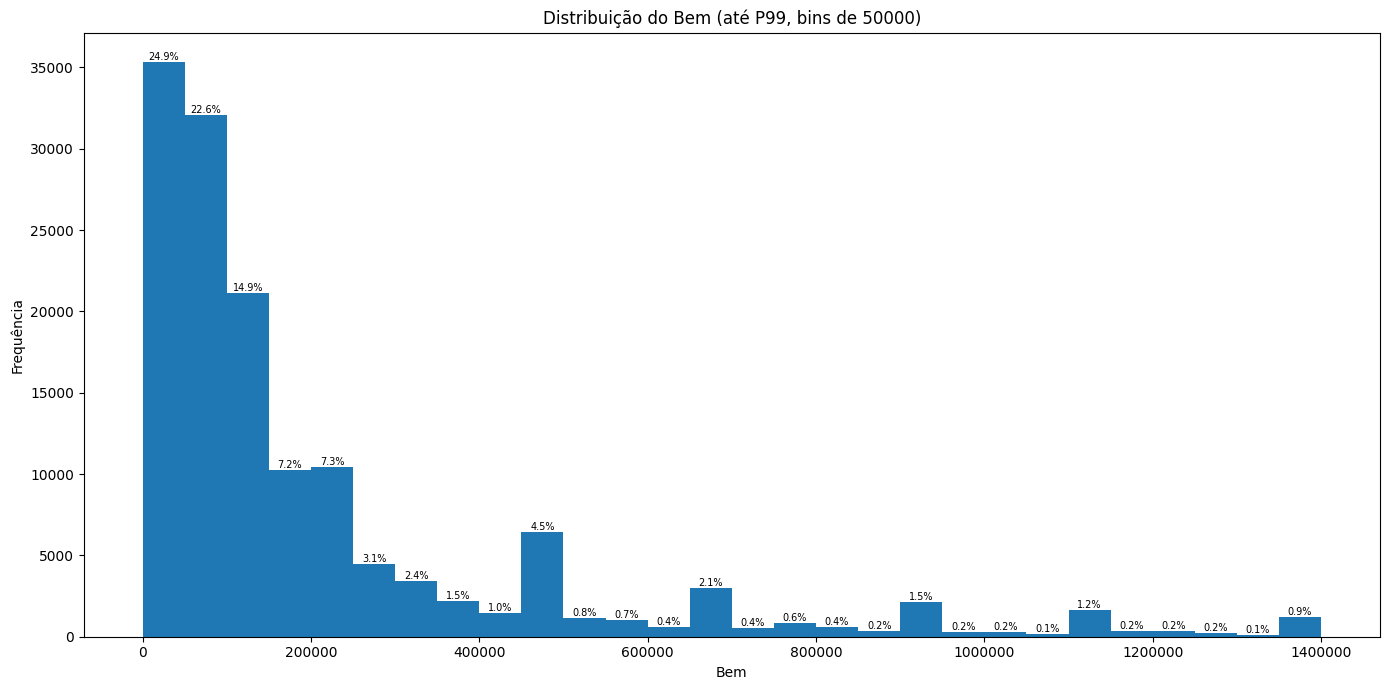

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# Original data
data = historico_emprestimos['valor_bem']

# ✅ Option 1: clip at 99th percentile
p99 = data.quantile(0.99)
data_clipped = data[data <= p99]

plt.figure(figsize=(14, 7))

# Bins of 5000
bins = np.arange(data_clipped.min(), data_clipped.max() + 50000, 50000)

counts, bins, patches = plt.hist(data_clipped, bins=bins)

# Percentages
percentages = counts / counts.sum() * 100

# Add % labels
for count, pct, patch in zip(counts, percentages, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{pct:.1f}%",
            ha='center',
            va='bottom',
            fontsize=7
        )

# Fix axis formatting (no scientific notation)
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

plt.title("Distribuição do Bem (até P99, bins de 50000)")
plt.xlabel("Bem")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [71]:
historico_emprestimos['valor_bem'].describe()

count    1.434530e+05
mean     2.267213e+05
std      3.128649e+05
min      0.000000e+00
25%      5.085000e+04
50%      1.120365e+05
75%      2.339100e+05
max      3.825000e+06
Name: valor_bem, dtype: float64

# Valor Parcela

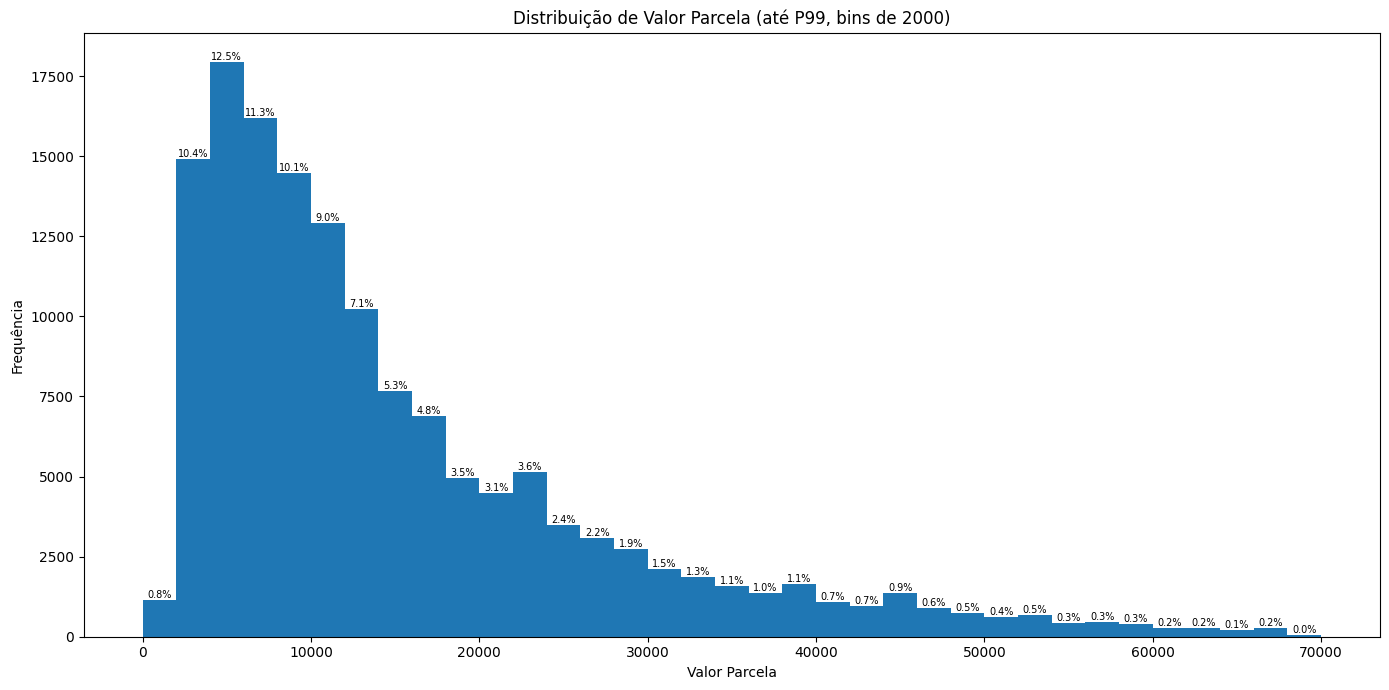

In [72]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# Original data
data = historico_emprestimos['valor_parcela']

# ✅ Option 1: clip at 99th percentile
p99 = data.quantile(0.99)
data_clipped = data[data <= p99]

plt.figure(figsize=(14, 7))

# Bins of 5000
bins = np.arange(data_clipped.min(), data_clipped.max() + 2000, 2000)

counts, bins, patches = plt.hist(data_clipped, bins=bins)

# Percentages
percentages = counts / counts.sum() * 100

# Add % labels
for count, pct, patch in zip(counts, percentages, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{pct:.1f}%",
            ha='center',
            va='bottom',
            fontsize=7
        )

# Fix axis formatting (no scientific notation)
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

plt.title("Distribuição de Valor Parcela (até P99, bins de 2000)")
plt.xlabel("Valor Parcela")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [73]:
historico_emprestimos['valor_parcela'].describe()

count    145126.000000
mean      15904.691449
std       14777.235207
min           0.000000
25%        6312.735000
50%       11250.000000
75%       20559.757500
max      417927.645000
Name: valor_parcela, dtype: float64

# Valor Entrada

In [74]:
historico_emprestimos['valor_entrada'].isna().sum()

np.int64(100168)

Preenchendo o valor_entrada com mediana para evitar influência de outliers.

In [75]:
historico_emprestimos['valor_entrada'] = historico_emprestimos['valor_entrada'].fillna(
    historico_emprestimos['valor_entrada'].median()
)

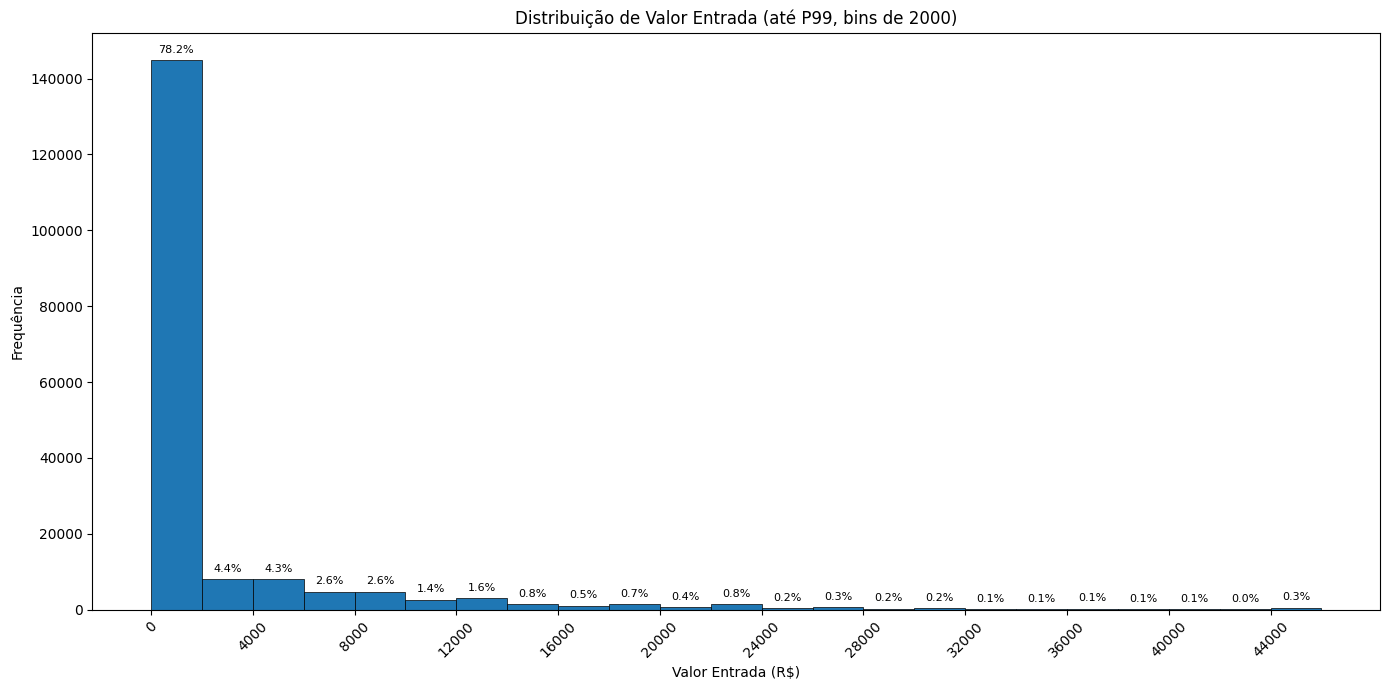

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# 1. Preparação dos dados
data = historico_emprestimos['valor_entrada'].dropna()
p99 = data.quantile(0.99)
data_clipped = data[data <= p99]

plt.figure(figsize=(14, 7))

# 2. Definição dos bins (intervalos de 2000 em 2000)
# Usamos p99 + 2000 no stop para garantir que a última barra apareça completa
custom_bins = np.arange(0, p99 + 2000, 2000)

# 3. Plotagem do Histograma
counts, bins, patches = plt.hist(
    data_clipped, 
    bins=custom_bins, 
    edgecolor='black',  # Adiciona a borda para separar as barras
    linewidth=0.5
)

# 4. Cálculo e Adição das Porcentagens
total = counts.sum()
for count, patch in zip(counts, patches):
    if count > 0:
        percentage = (count / total) * 100
        plt.text(
            patch.get_x() + patch.get_width()/2, # Centro da barra
            count + (max(counts) * 0.01),        # Pequeno offset acima da barra
            f'{percentage:.1f}%', 
            ha='center', 
            va='bottom', 
            fontsize=8
        )

# 5. Formatação dos Eixos
plt.title("Distribuição de Valor Entrada (até P99, bins de 2000)")
plt.xlabel("Valor Entrada (R$)")
plt.ylabel("Frequência")

# Define os ticks do eixo X para baterem com os bins (mostrando de 4000 em 4000 para não poluir)
plt.xticks(custom_bins[::2], rotation=45) 

# Remove notação científica
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

In [77]:
historico_emprestimos['valor_entrada'].describe()

count    1.868900e+05
mean     3.968938e+03
std      1.414844e+04
min      0.000000e+00
25%      1.575000e+03
50%      1.575000e+03
75%      1.575000e+03
max      1.344510e+06
Name: valor_entrada, dtype: float64

# Percentual de entrada

In [78]:
historico_emprestimos['percentual_entrada'].isna().sum()
historico_emprestimos['percentual_entrada'] = historico_emprestimos['percentual_entrada'].fillna(
    historico_emprestimos['percentual_entrada'].median()
)


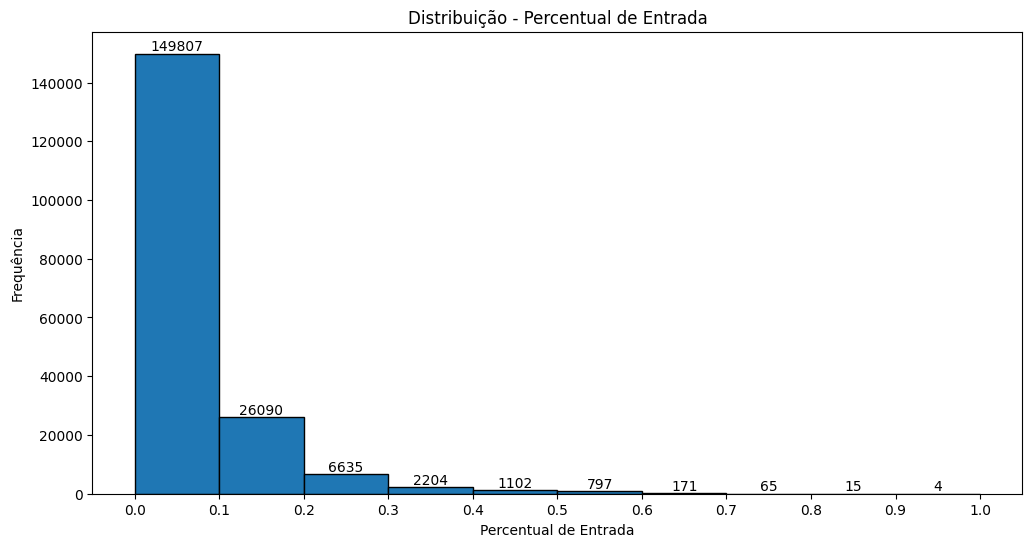

In [79]:
import matplotlib.pyplot as plt
import numpy as np

data = historico_emprestimos['percentual_entrada'].dropna()

plt.figure(figsize=(12,6))

# Define bins from 0 to 1 with a step of 0.1 (10% increments)
# This creates bins: [0.0, 0.1, 0.2, ..., 1.0]
custom_bins = np.arange(0, 1.1, 0.1)

counts, bins, patches = plt.hist(
    data,
    bins=custom_bins,
    edgecolor='black'
)

plt.title('Distribuição - Percentual de Entrada')
plt.xlabel('Percentual de Entrada')
plt.ylabel('Frequência')

# Force x-axis to show the percentages clearly
plt.xticks(custom_bins)

# Add value labels on top of bars
for count, left_edge, right_edge in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        x = (left_edge + right_edge) / 2
        y = count
        plt.text(x, y, f'{int(count)}', ha='center', va='bottom', fontsize=10)

plt.show()

In [80]:
historico_emprestimos['percentual_entrada'].describe()

count    186890.000000
mean          0.064060
std           0.075365
min           0.000000
25%           0.050340
50%           0.050340
75%           0.050340
max           0.989740
Name: percentual_entrada, dtype: float64

### Quantidade parcelas planejadas

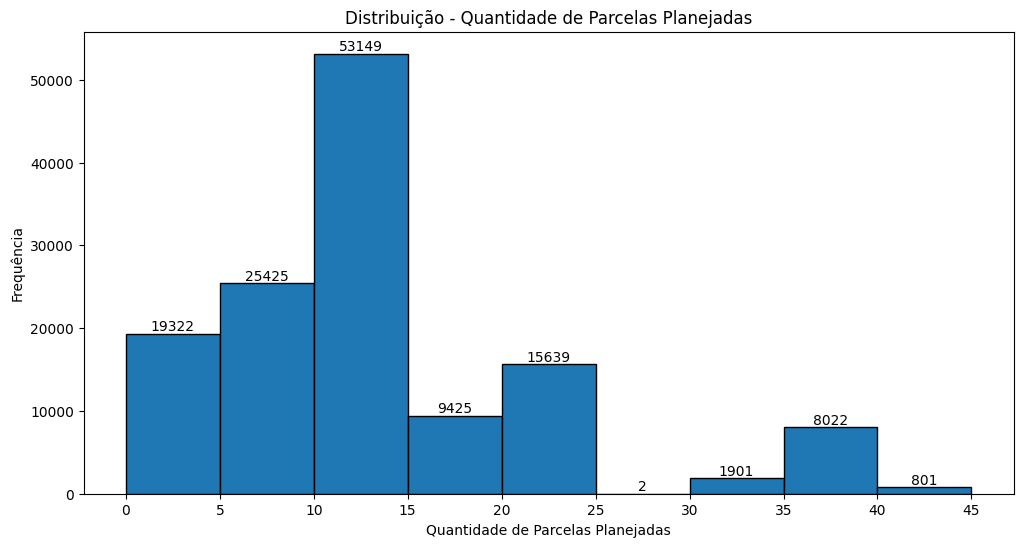

In [81]:
import matplotlib.pyplot as plt

data = historico_emprestimos['qtd_parcelas_planejadas'].dropna()

plt.figure(figsize=(12,6))

custom_bins = [b for b in range(0, 50, 5)]
counts, bins, patches = plt.hist(
    data,
    bins=custom_bins, 
    edgecolor='black'
)

plt.title('Distribuição - Quantidade de Parcelas Planejadas')
plt.xlabel('Quantidade de Parcelas Planejadas')
plt.ylabel('Frequência')

# Set x-ticks to match your bins for better readability
plt.xticks(custom_bins)

# Add value per bin
for count, left_edge, right_edge in zip(counts, bins[:-1], bins[1:]):
    x = (left_edge + right_edge) / 2
    y = count
    # Only show text if there is actually data in the bin
    if int(count) > 0:
        plt.text(x, y, f'{int(count)}', ha='center', va='bottom')

plt.show()

# Tipo pagamento

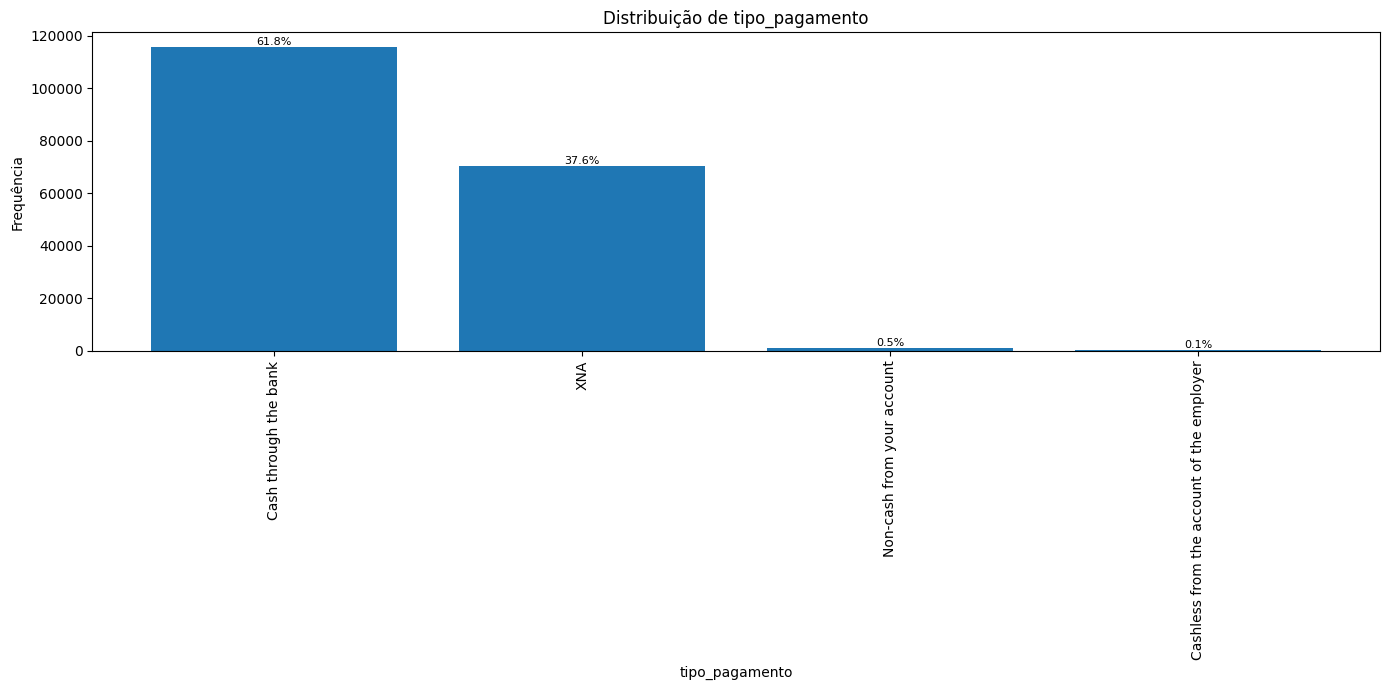

In [82]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['tipo_pagamento'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de tipo_pagamento")
plt.xlabel("tipo_pagamento")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Finalidade emprestimo

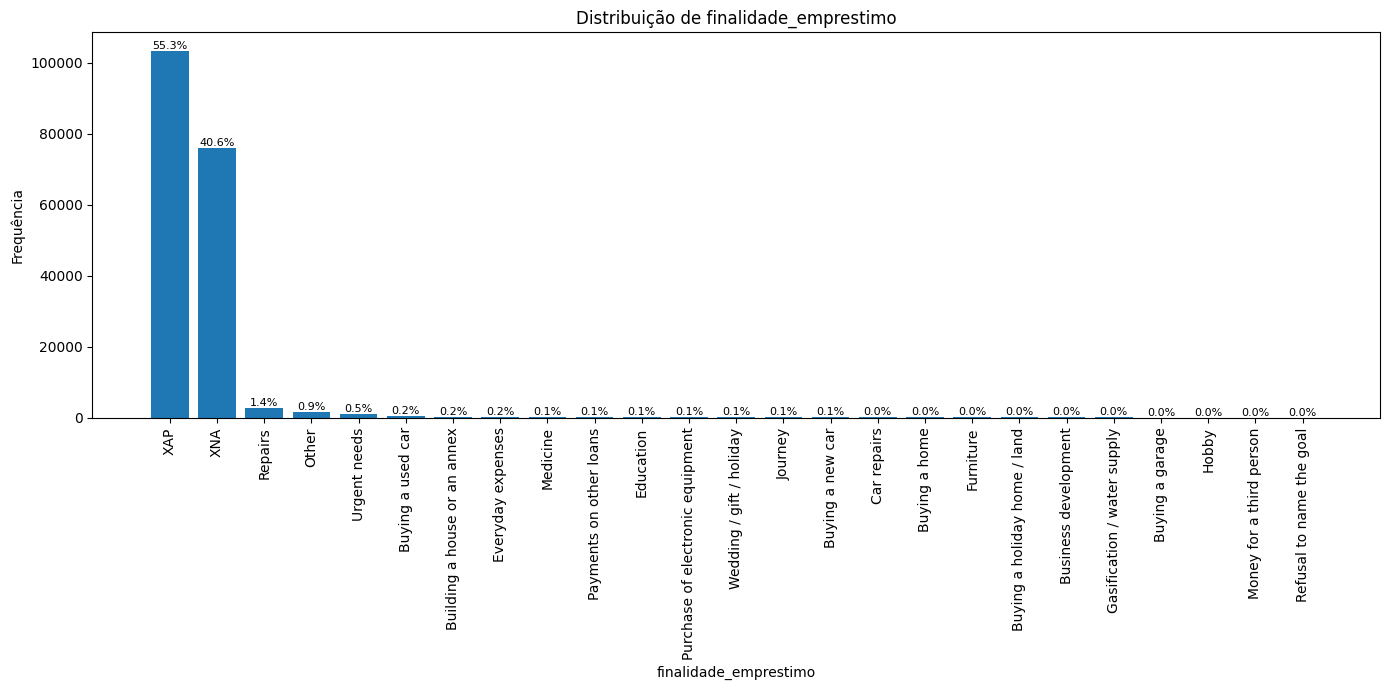

In [83]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['finalidade_emprestimo'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de finalidade_emprestimo")
plt.xlabel("finalidade_emprestimo")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Tipo Cliente

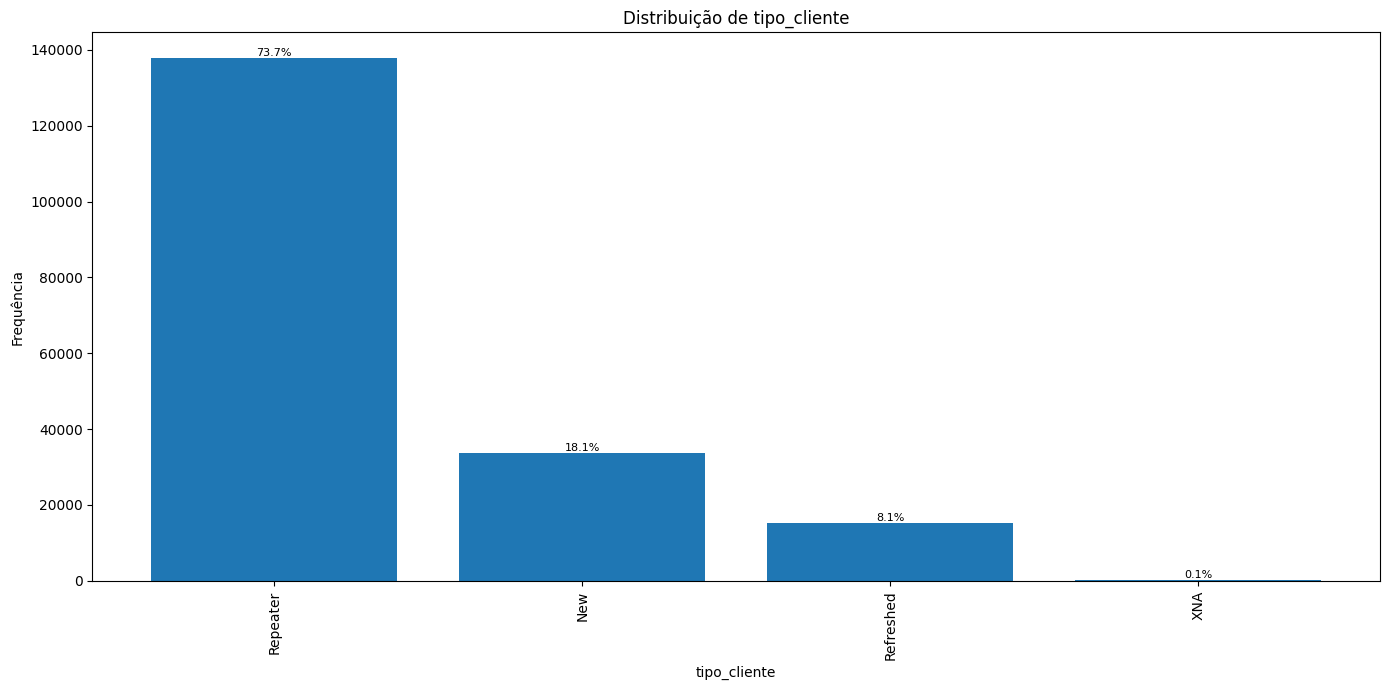

In [84]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['tipo_cliente'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de tipo_cliente")
plt.xlabel("tipo_cliente")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Faixa de rendimento

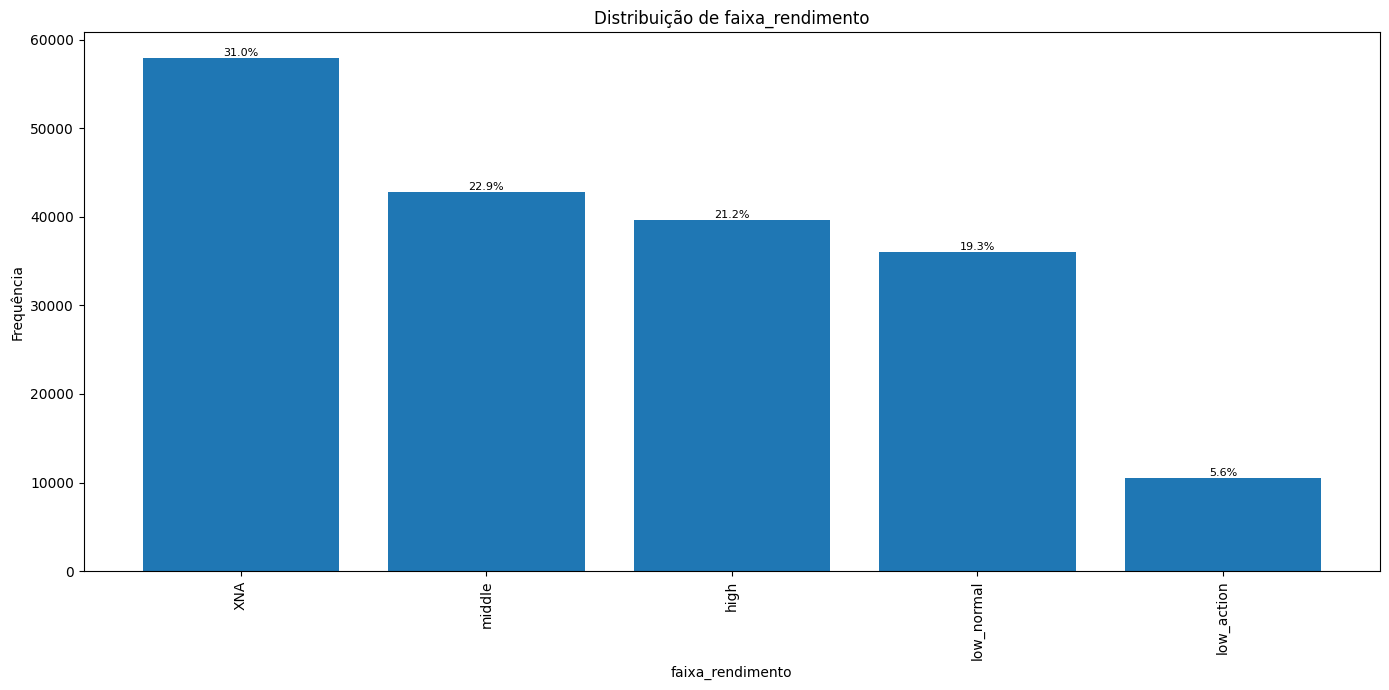

In [85]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['faixa_rendimento'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de faixa_rendimento")
plt.xlabel("faixa_rendimento")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Tipo portfolio

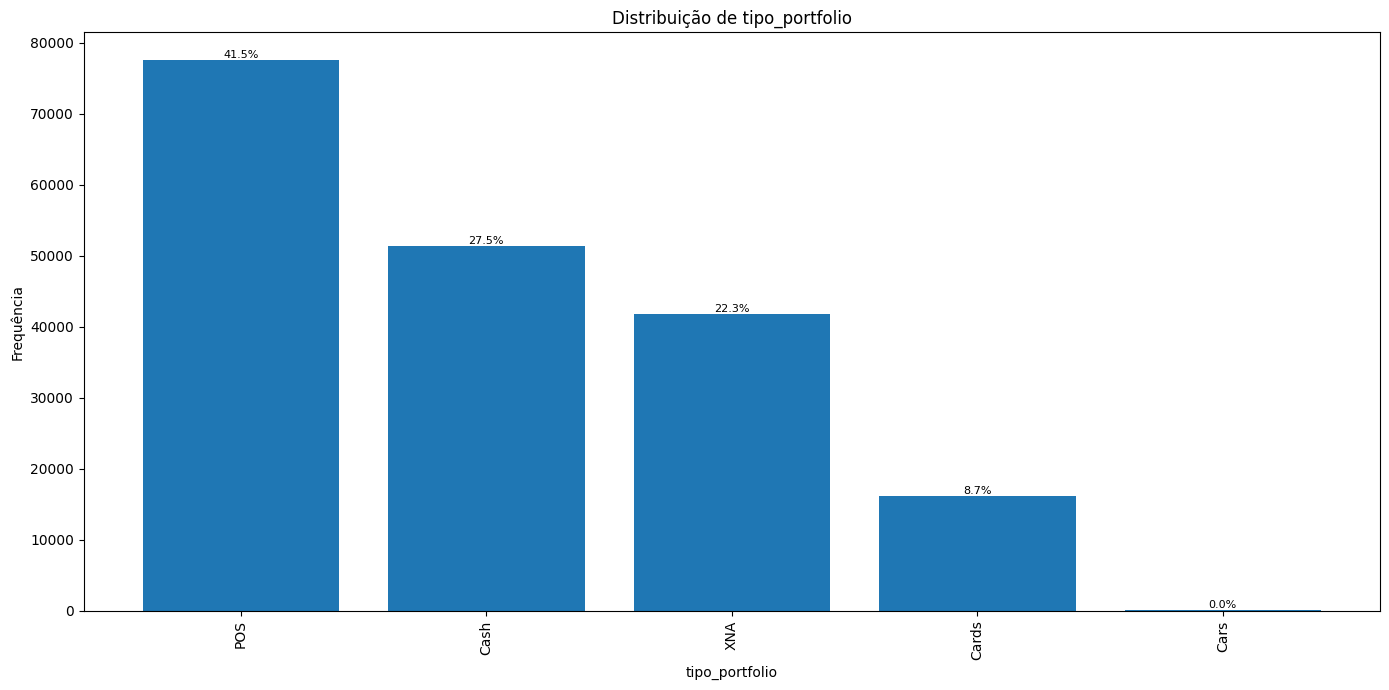

In [86]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['tipo_portfolio'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de tipo_portfolio")
plt.xlabel("tipo_portfolio")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Tipo Produto

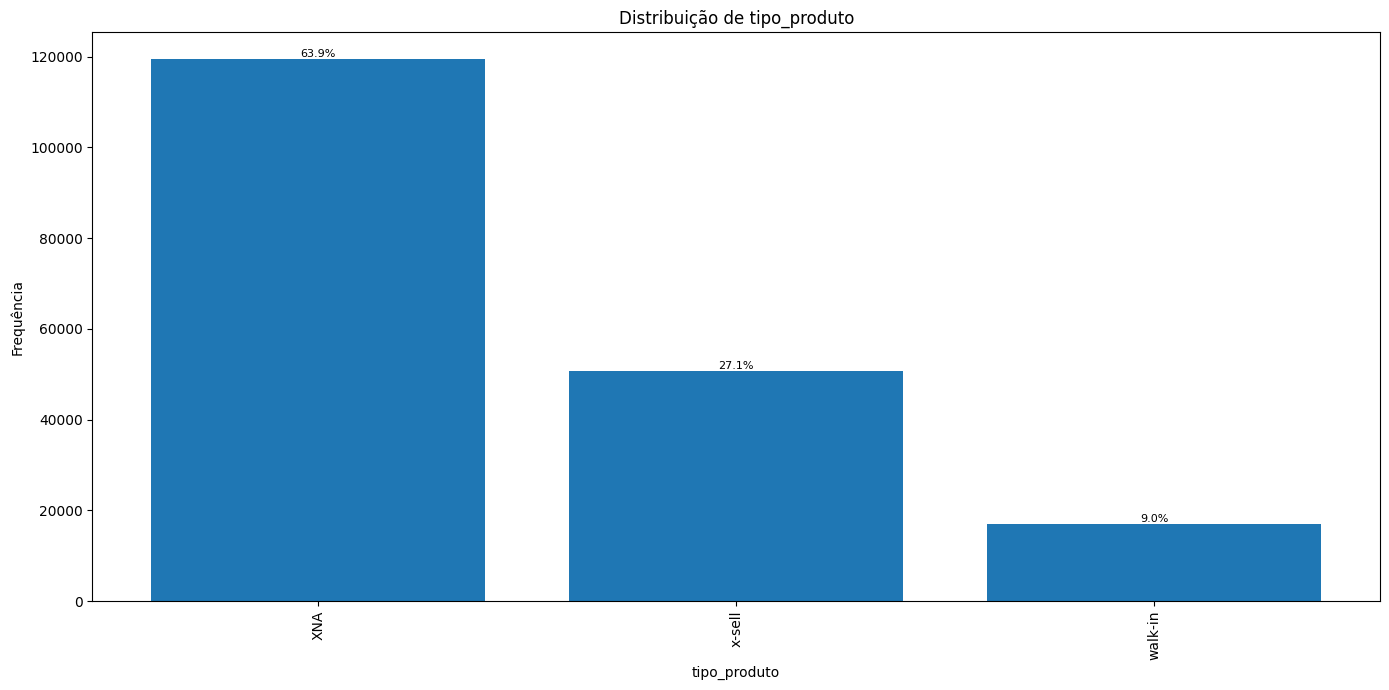

In [87]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['tipo_produto'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de tipo_produto")
plt.xlabel("tipo_produto")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Categoria bem

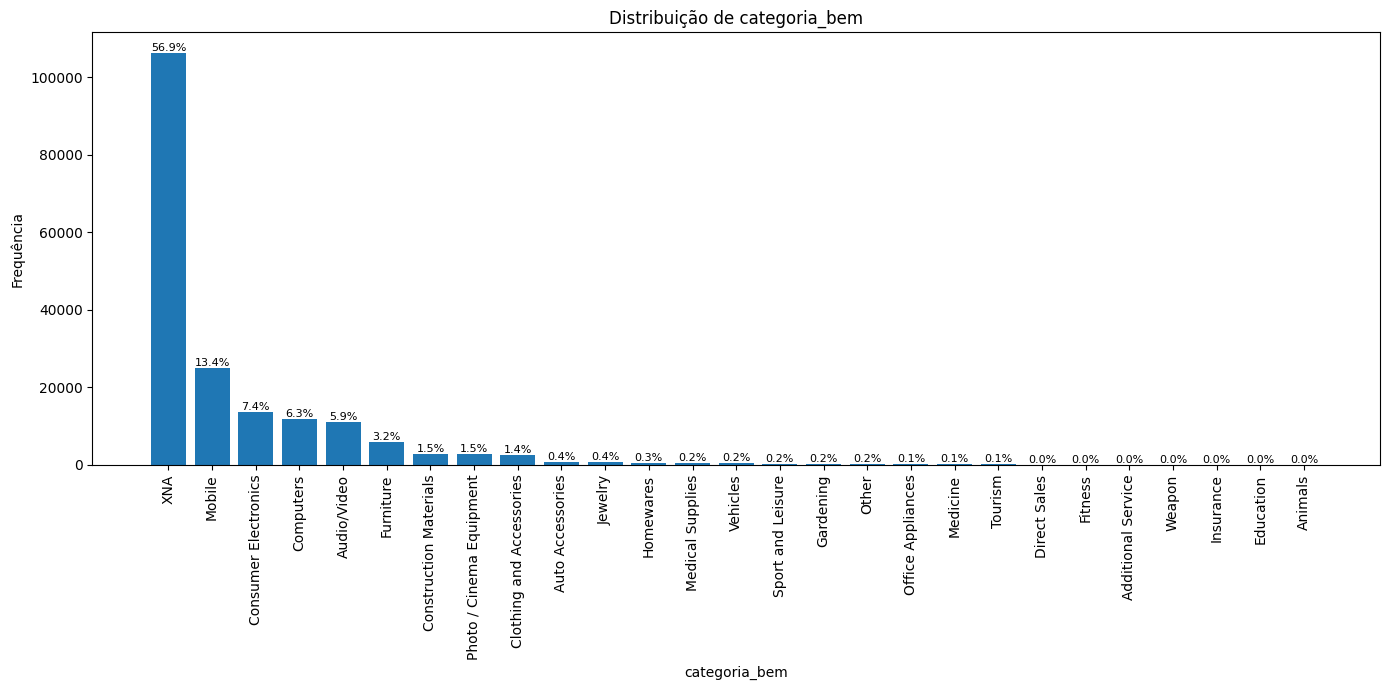

In [88]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['categoria_bem'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de categoria_bem")
plt.xlabel("categoria_bem")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Combinacao produto

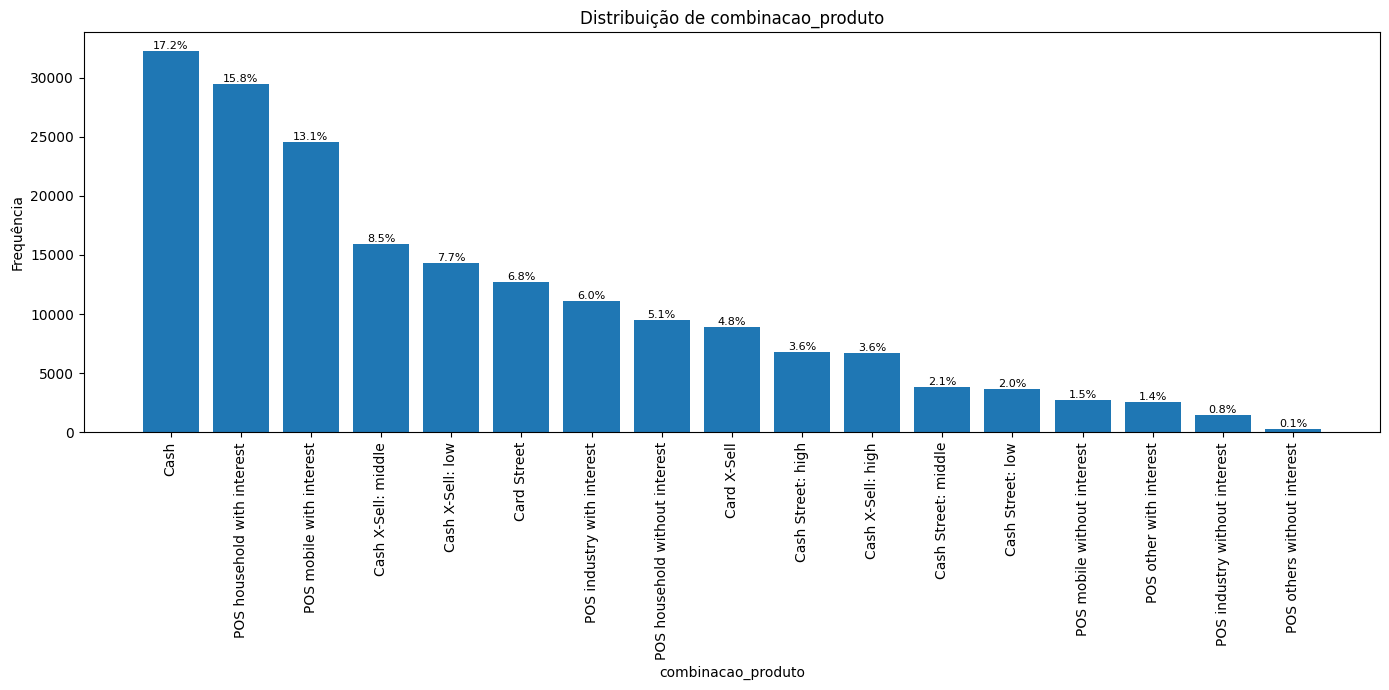

In [89]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['combinacao_produto'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de combinacao_produto")
plt.xlabel("combinacao_produto")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Setor vendedor

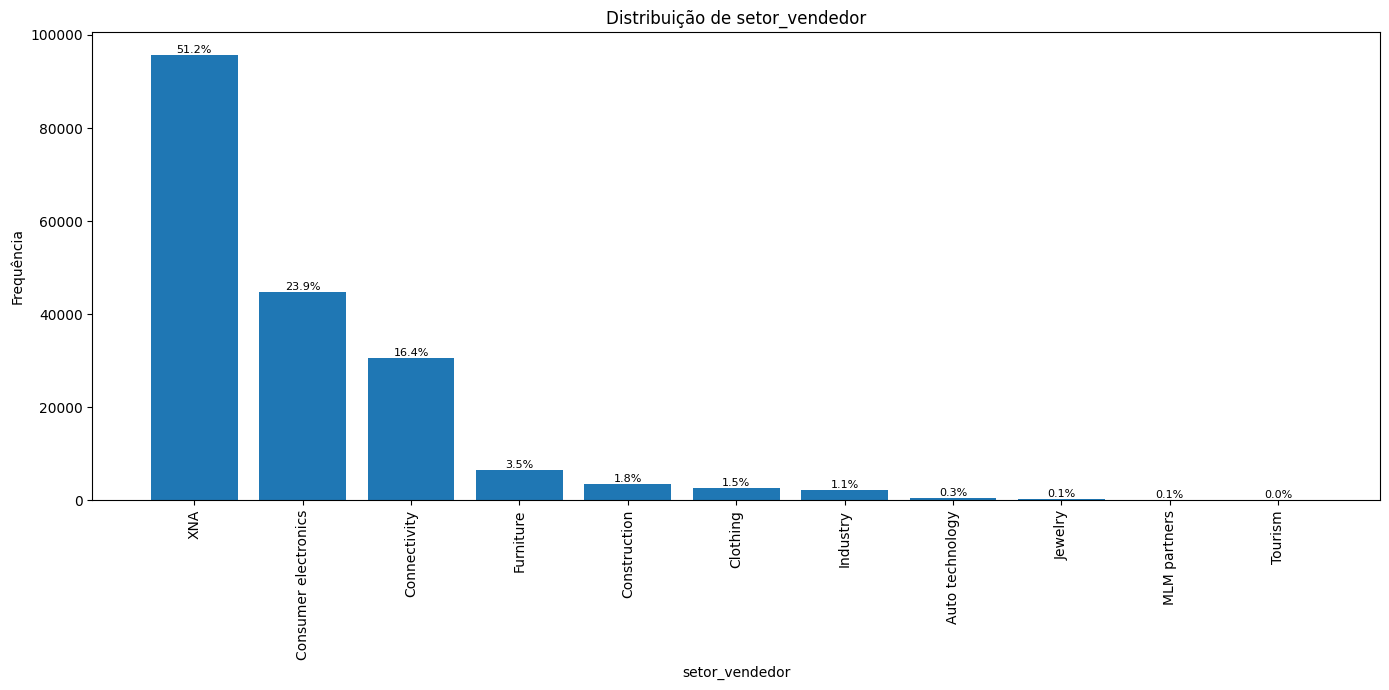

In [90]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['setor_vendedor'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de setor_vendedor")
plt.xlabel("setor_vendedor")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Canal Venda

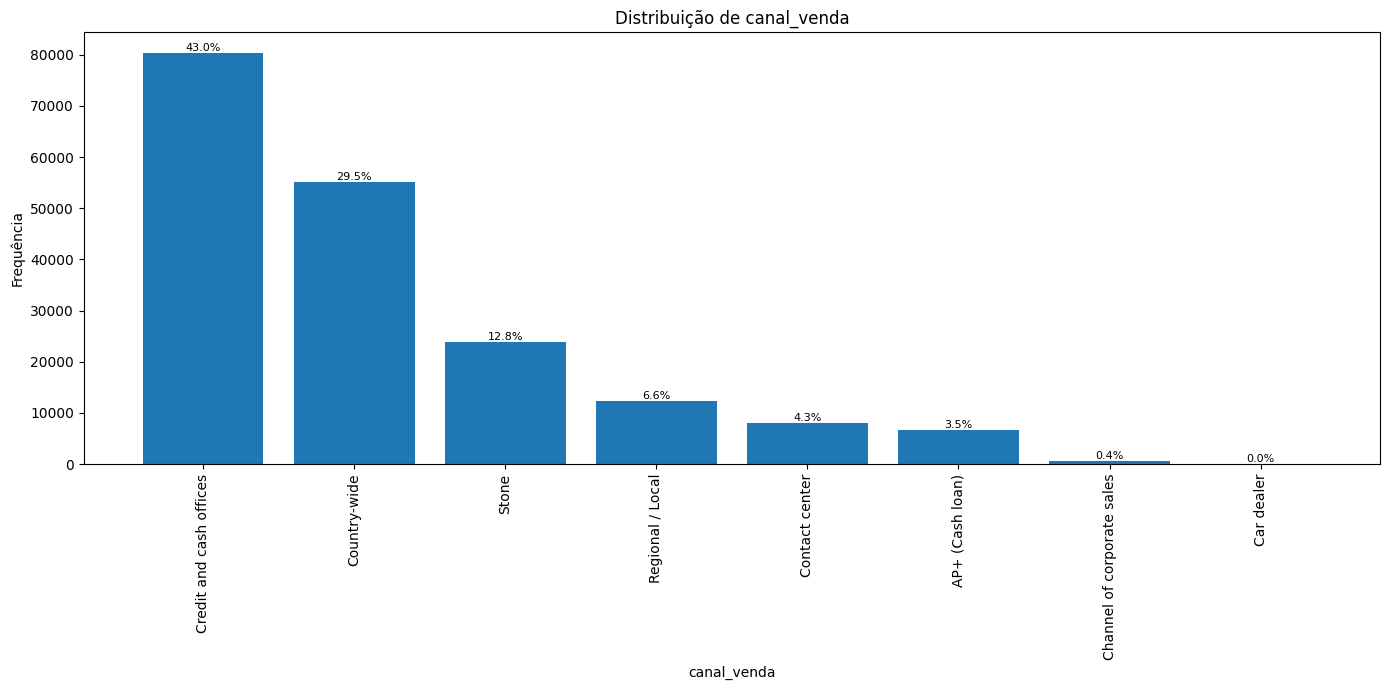

In [91]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['canal_venda'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de canal_venda")
plt.xlabel("canal_venda")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Area venda

In [92]:
historico_emprestimos['area_venda'].unique()

array([  -1, 2078,   95, ...,  966, 1633,  562], shape=(1614,))

### Por haver muitas branches, (1614), plotando as top 20.

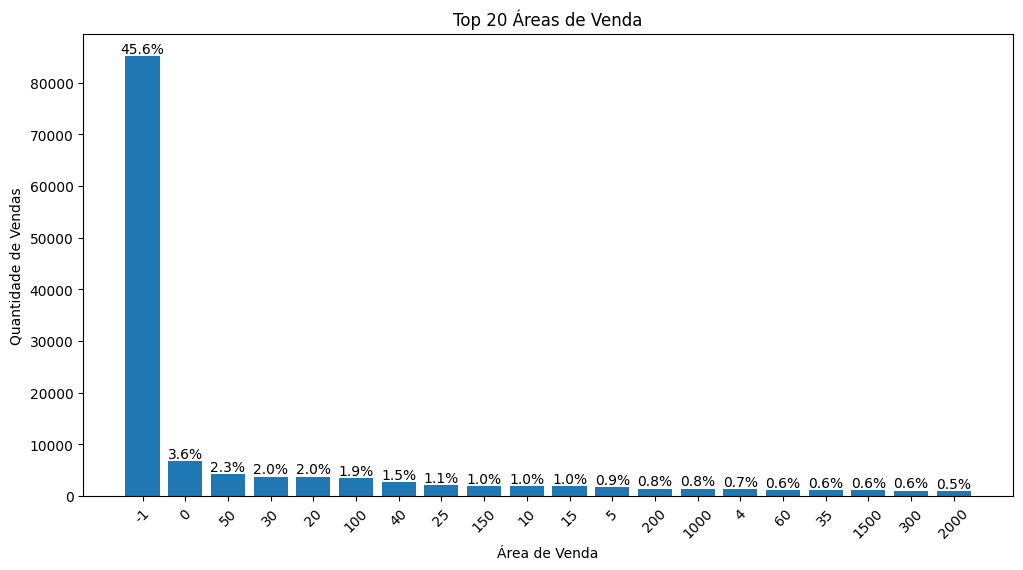

In [93]:
import matplotlib.pyplot as plt

top_20 = historico_emprestimos['area_venda'].value_counts().head(20)

percentages = top_20 / historico_emprestimos.shape[0] * 100

plt.figure(figsize=(12,6))
bars = plt.bar(top_20.index.astype(str), top_20.values)

plt.title('Top 20 Áreas de Venda')
plt.xlabel('Área de Venda')
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=45)

# Add percentage labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

# Dia semana solicitação

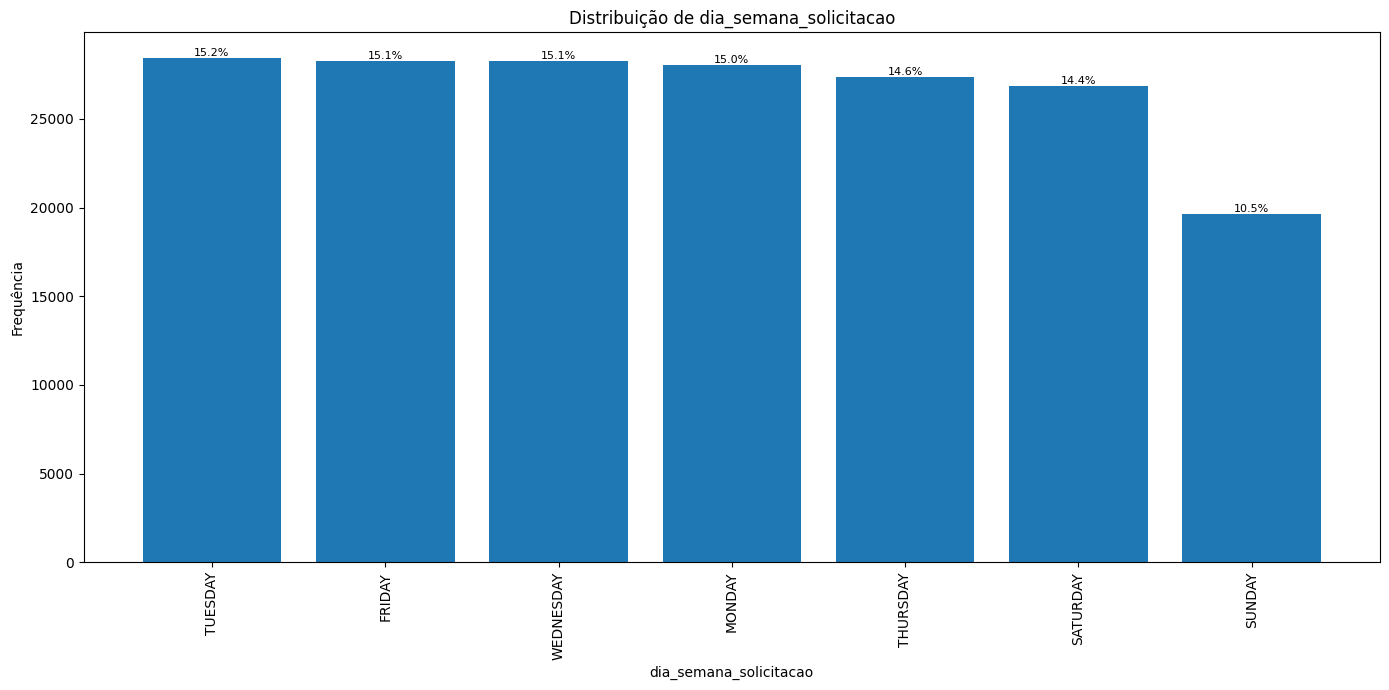

In [94]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['dia_semana_solicitacao'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de dia_semana_solicitacao")
plt.xlabel("dia_semana_solicitacao")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Hora solicitacao

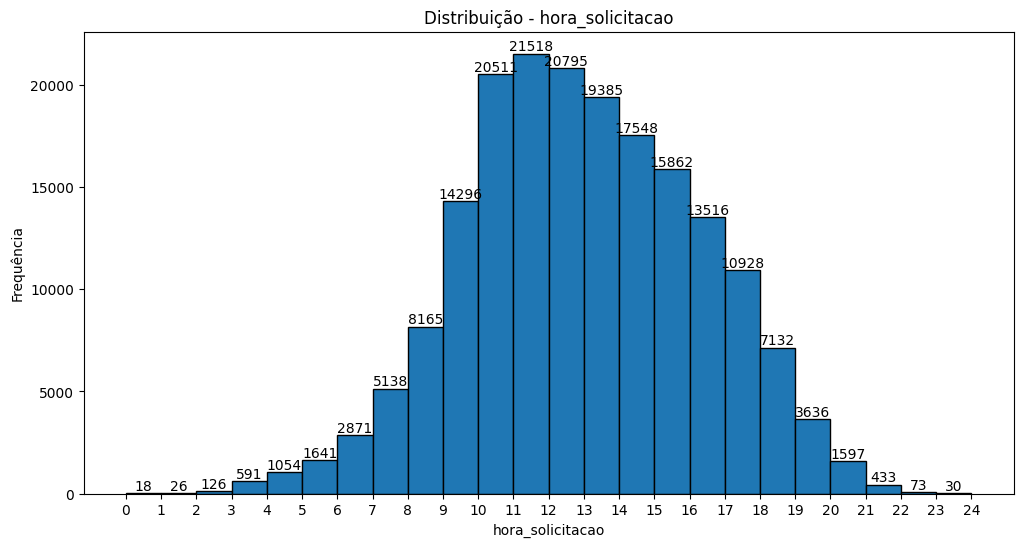

In [95]:
import matplotlib.pyplot as plt

data = historico_emprestimos['hora_solicitacao'].dropna()

plt.figure(figsize=(12,6))

custom_bins = [b for b in range(0, 25, 1)]
counts, bins, patches = plt.hist(
    data,
    bins=custom_bins, 
    edgecolor='black'
)

plt.title('Distribuição - hora_solicitacao')
plt.xlabel('hora_solicitacao')
plt.ylabel('Frequência')

# Set x-ticks to match your bins for better readability
plt.xticks(custom_bins)

# Add value per bin
for count, left_edge, right_edge in zip(counts, bins[:-1], bins[1:]):
    x = (left_edge + right_edge) / 2
    y = count
    # Only show text if there is actually data in the bin
    if int(count) > 0:
        plt.text(x, y, f'{int(count)}', ha='center', va='bottom')

plt.show()

# Acompanhante Cliente

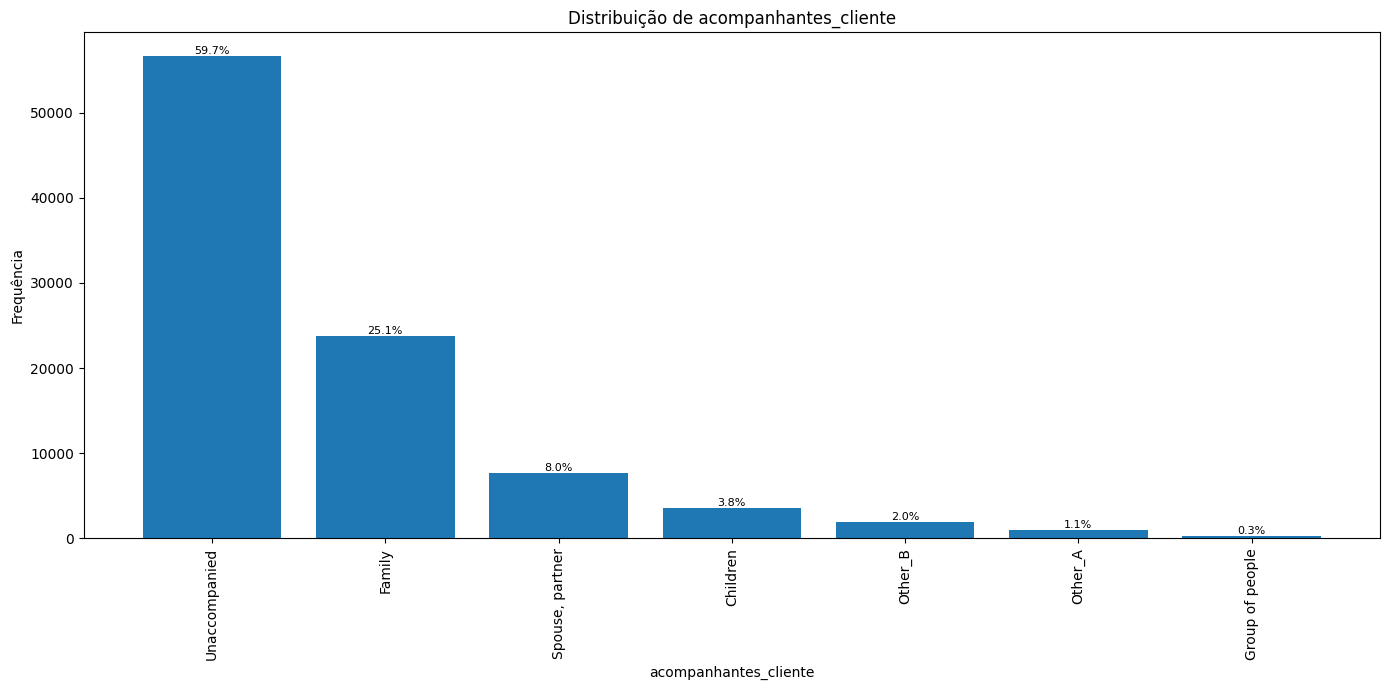

In [96]:
import matplotlib.pyplot as plt

counts = historico_emprestimos['acompanhantes_cliente'].value_counts()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(counts.index, counts.values)

# Add % labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição de acompanhantes_cliente")
plt.xlabel("acompanhantes_cliente")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Seguro contratado

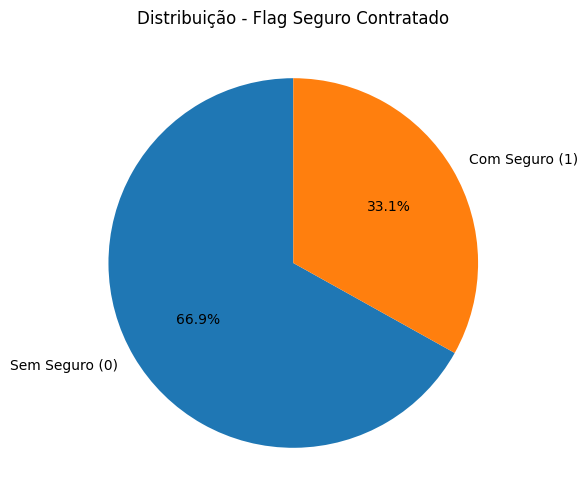

In [97]:
import matplotlib.pyplot as plt

data = historico_emprestimos['flag_seguro_contratado'].dropna().value_counts()

labels = ['Sem Seguro (0)', 'Com Seguro (1)']

plt.figure(figsize=(6,6))
plt.pie(
    data,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribuição - Flag Seguro Contratado')
plt.show()

# Historico de parcelas

In [98]:
print(historico_parcelas.shape)
print(historico_parcelas.columns)

(1390978, 8)
Index(['id_contrato', 'id_cliente', 'versao_parcela', 'numero_parcela',
       'data_prevista_pagamento', 'data_real_pagamento',
       'valor_previsto_parcela', 'valor_pago_parcela'],
      dtype='str')


In [99]:
# Porcentagem de itens nulos
(historico_parcelas.isnull().sum()/base_cadastral.shape[0] * 100).round(2)

id_contrato                0.00
id_cliente                 0.00
versao_parcela             0.00
numero_parcela             0.00
data_prevista_pagamento    0.00
data_real_pagamento        0.85
valor_previsto_parcela     0.00
valor_pago_parcela         0.85
dtype: float64

In [100]:
historico_parcelas.dtypes

id_contrato                  int64
id_cliente                   int64
versao_parcela             float64
numero_parcela               int64
data_prevista_pagamento        str
data_real_pagamento            str
valor_previsto_parcela     float64
valor_pago_parcela         float64
dtype: object

In [101]:
print(f'Id contrato unico: {historico_parcelas['id_contrato'].nunique()}')
print(f'Id cliente unico: {historico_parcelas['id_cliente'].nunique()}')

Id contrato unico: 107419
Id cliente unico: 37739


# Inadimplencia

In [102]:
historico_parcelas['data_prevista_pagamento'] = pd.to_datetime(
    historico_parcelas['data_prevista_pagamento'],
    errors='coerce'
)

historico_parcelas['data_real_pagamento'] = pd.to_datetime(
    historico_parcelas['data_real_pagamento'],
    errors='coerce'
)

### Distribuição em atraso de pagamento

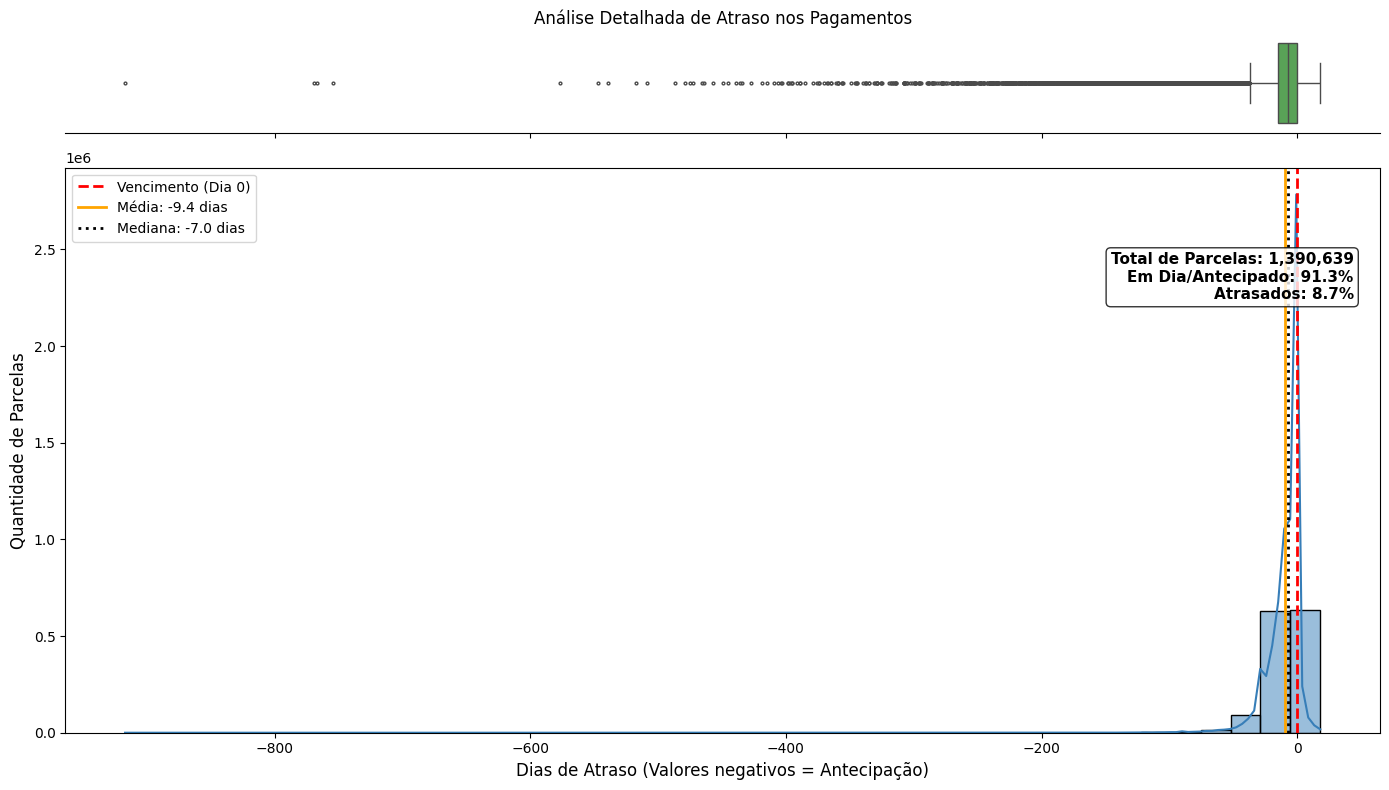

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Preparação dos dados
# (Assumindo que df['atraso_dias'] já foi calculado conforme seu código anterior)
df = historico_parcelas.dropna(subset=['data_prevista_pagamento', 'data_real_pagamento']).copy()
df['atraso_dias'] = (df['data_real_pagamento'] - df['data_prevista_pagamento']).dt.days

# Filtramos outliers extremos para o gráfico não ficar ilegível (ex: p99)
limite_visual = df['atraso_dias'].quantile(0.99)
df_plot = df[df['atraso_dias'] <= limite_visual]

# 2. Configuração do Layout (Boxplot em cima, Histograma embaixo)
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                    gridspec_kw={"height_ratios": (.15, .85)}, 
                                    figsize=(14, 8))

# 3. Boxplot (Topo) - Útil para identificar a dispersão e mediana rapidamente
sns.boxplot(x=df_plot["atraso_dias"], ax=ax_box, color="#4daf4a", fliersize=2)
ax_box.set(xlabel='', yticks=[], title='Análise Detalhada de Atraso nos Pagamentos')
sns.despine(ax=ax_box, left=True)

# 4. Histograma (Base) com Curva de Densidade (KDE)
sns.histplot(data=df_plot, x="atraso_dias", kde=True, ax=ax_hist, color="#377eb8", bins=40, edgecolor='black')

# 5. Linhas de Referência Estatística
mean_val = df['atraso_dias'].mean()
median_val = df['atraso_dias'].median()

ax_hist.axvline(0, color='red', linestyle='--', linewidth=2, label='Vencimento (Dia 0)')
ax_hist.axvline(mean_val, color='orange', linestyle='-', linewidth=2, label=f'Média: {mean_val:.1f} dias')
ax_hist.axvline(median_val, color='black', linestyle=':', linewidth=2, label=f'Mediana: {median_val:.1f} dias')

# 6. Cálculo de métricas de negócio para exibição
total = len(df)
atrasados = len(df[df['atraso_dias'] > 0])
em_dia = total - atrasados
taxa_atraso = (atrasados / total) * 100

# Adicionando caixa de texto com o resumo
resumo_texto = f'Total de Parcelas: {total:,}\nEm Dia/Antecipado: {em_dia/total:.1%}\nAtrasados: {taxa_atraso:.1f}%'
plt.text(0.98, 0.85, resumo_texto, transform=ax_hist.transAxes, 
         fontsize=11, fontweight='bold', va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 7. Ajustes de Eixos e Legendas
ax_hist.set_xlabel('Dias de Atraso (Valores negativos = Antecipação)', fontsize=12)
ax_hist.set_ylabel('Quantidade de Parcelas', fontsize=12)
ax_hist.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Pedido vs efetivado

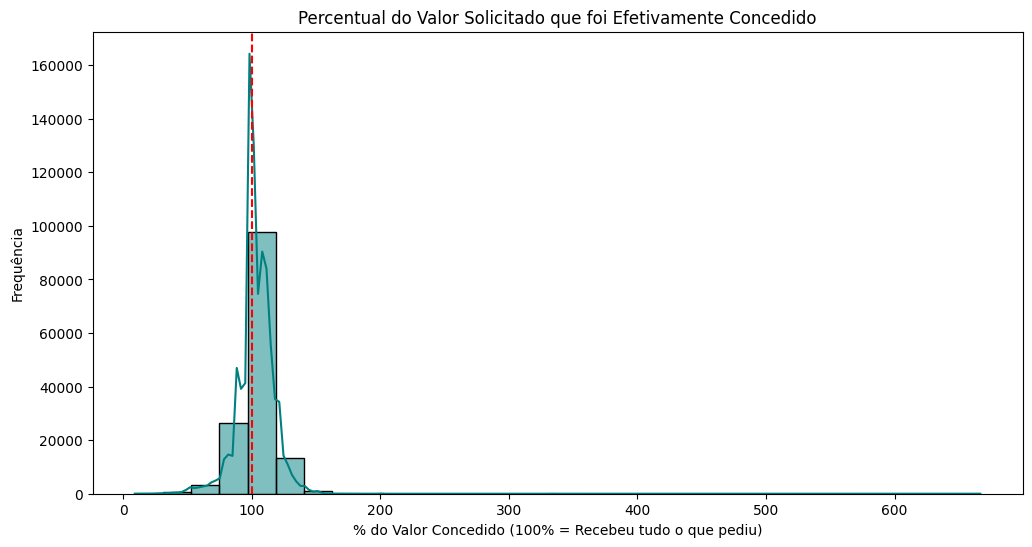

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criar uma coluna de diferença percentual
df_emp = historico_emprestimos.copy()
df_emp['diff_solicitado_credito'] = (df_emp['valor_credito'] / df_emp['valor_solicitado']) * 100

plt.figure(figsize=(12, 6))
sns.histplot(df_emp['diff_solicitado_credito'], bins=30, kde=True, color='teal')

plt.title('Percentual do Valor Solicitado que foi Efetivamente Concedido')
plt.xlabel('% do Valor Concedido (100% = Recebeu tudo o que pediu)')
plt.ylabel('Frequência')
plt.axvline(100, color='red', linestyle='--')
plt.show()

* Discrepância: Solicitado vs. Aprovado
* Esta análise mostra se o banco está entregando o que o cliente pede. Se houver muita diferença, o cliente pode ficar insatisfeito ou o risco pode ser muito alto.

# Ticket médio por motivo de empréstimo

/tmp/ipykernel_258369/1732323943.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_emp, x='valor_credito', y='finalidade_emprestimo', order=order, palette='viridis')


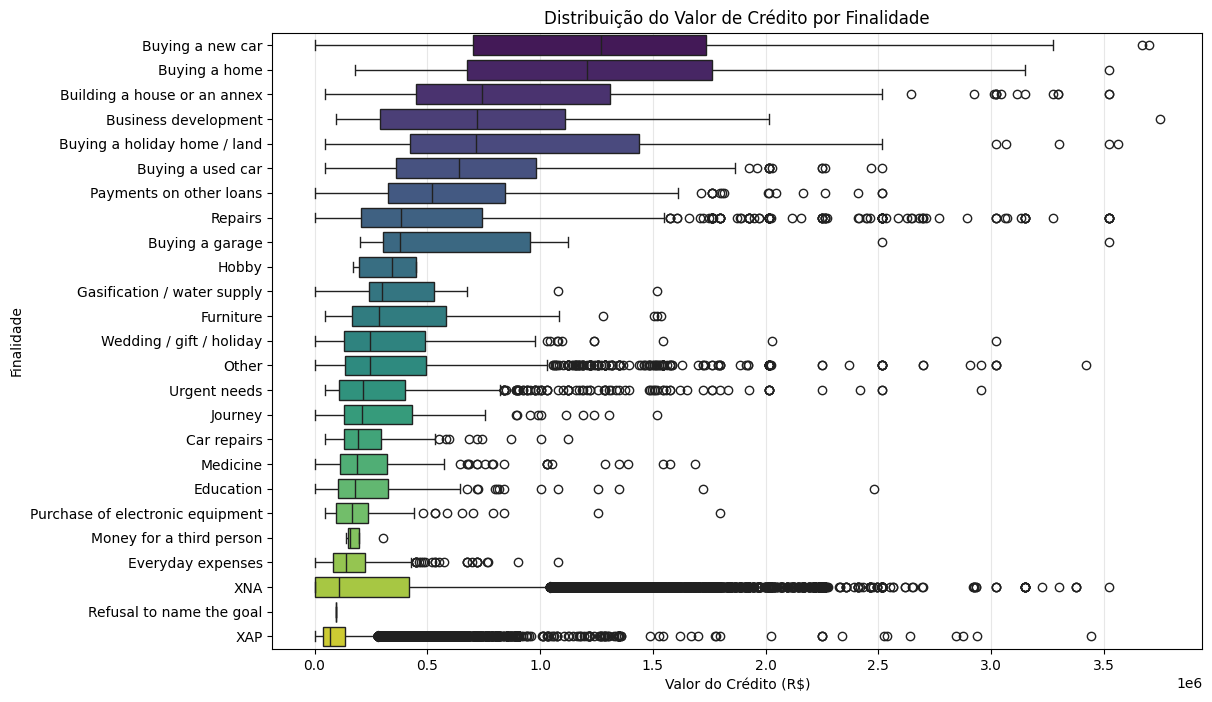

In [106]:
plt.figure(figsize=(12, 8))

# Calculando a média de valor por finalidade e ordenando
order = df_emp.groupby('finalidade_emprestimo')['valor_credito'].median().sort_values(ascending=False).index

sns.boxplot(data=df_emp, x='valor_credito', y='finalidade_emprestimo', order=order, palette='viridis')

plt.title('Distribuição do Valor de Crédito por Finalidade')
plt.xlabel('Valor do Crédito (R$)')
plt.ylabel('Finalidade')
plt.grid(axis='x', alpha=0.3)
plt.show()

# Volume de contrato por finalidade de emprestimo e ticket médio

/tmp/ipykernel_258369/1571578115.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=resumo_finalidade, x='quantidade', y='finalidade_emprestimo',


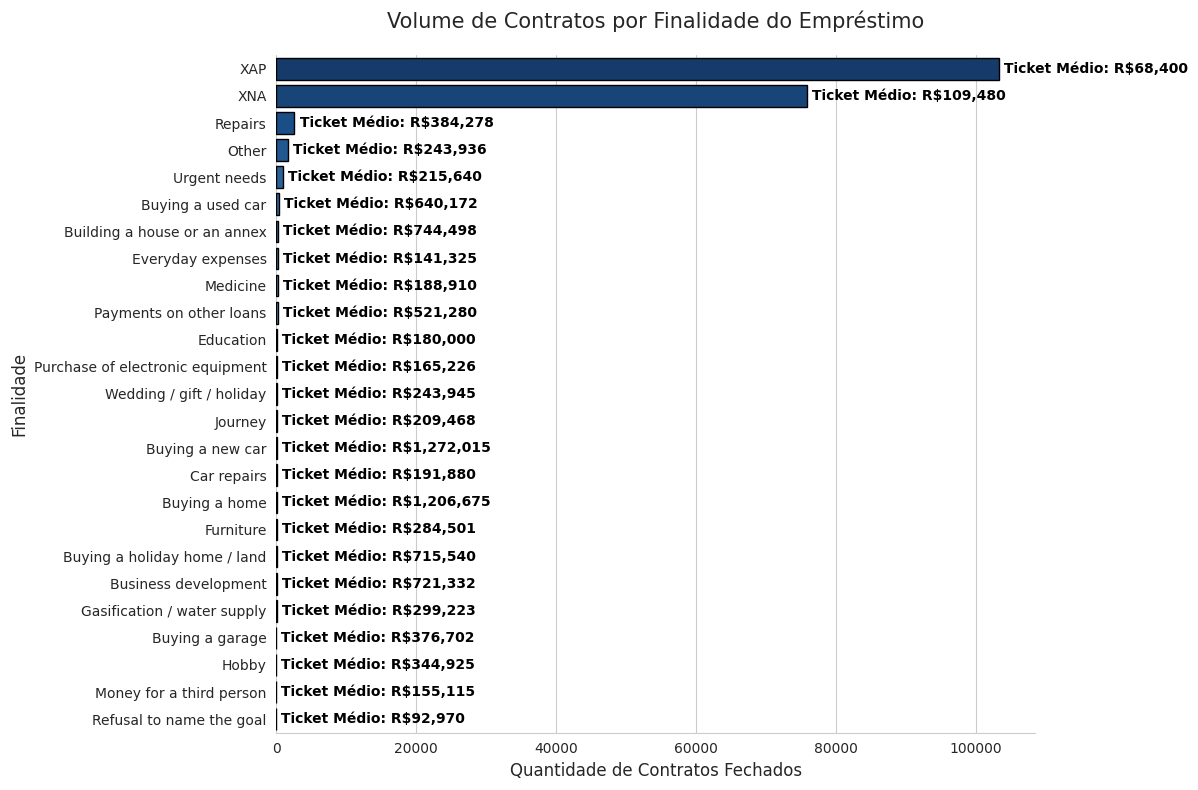

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Agrupar os dados para ver o volume e o valor médio por finalidade
resumo_finalidade = historico_emprestimos.groupby('finalidade_emprestimo').agg(
    quantidade=('id_contrato', 'count'),
    valor_medio=('valor_credito', 'median')
).sort_values('quantidade', ascending=False).reset_index()

# 2. Plotar
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Criando o gráfico de barras
ax = sns.barplot(data=resumo_finalidade, x='quantidade', y='finalidade_emprestimo', 
                 palette='Blues_r', edgecolor='black')

# Adicionando o valor médio escrito dentro/ao lado das barras
for i, p in enumerate(ax.patches):
    width = p.get_width()
    valor_m = resumo_finalidade.loc[i, 'valor_medio']
    ax.text(width + 1, p.get_y() + p.get_height()/2, 
            f' Ticket Médio: R${valor_m:,.0f}', 
            va='center', fontsize=10, color='black', fontweight='bold')

plt.title('Volume de Contratos por Finalidade do Empréstimo', fontsize=15, pad=20)
plt.xlabel('Quantidade de Contratos Fechados', fontsize=12)
plt.ylabel('Finalidade', fontsize=12)

# Remover bordas desnecessárias
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

# Distribuiçao dos prazos de Empréstimos (Número de parcelas)

/tmp/ipykernel_258369/1915716982.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=historico_emprestimos, x='qtd_parcelas_planejadas', palette='viridis')


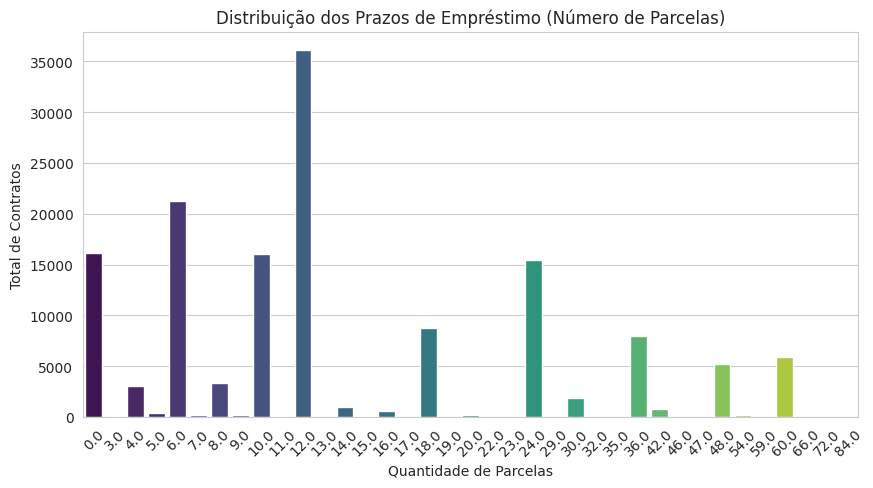

In [110]:
plt.figure(figsize=(10, 5))
sns.countplot(data=historico_emprestimos, x='qtd_parcelas_planejadas', palette='viridis')

plt.title('Distribuição dos Prazos de Empréstimo (Número de Parcelas)')
plt.xlabel('Quantidade de Parcelas')
plt.ylabel('Total de Contratos')
plt.xticks(rotation=45)
plt.show()